# Experiment 3: Sorting Kernels

This experiment explores different kernels for sorting fixed-sized arrays.
It is part of a larger effort to build a fast segmented sorting algorithm on
WebGPU. This work is based on Hou et. al's [Fast Segmented Sort on GPUs](https://dl.acm.org/doi/abs/10.1145/3079079.3079105).

There are four sorting methods being tested:
1.    smem: shared-memory-based bitonic sort networks - use workgroup memory to shuffle data between threads
2.    reg: register-based bitonic sort networks - use registers to shuffle data between threads
      This is the analog to the register-based sorting network created by Hou et. al.
3.    hybrid: hybrid bitonic sort networks - use registers to shuffle data until we are limited by subgroup size, then switch to shared memory
4.    hybmerge: hybrid bitonic sort + merge sort - use register to sort data until we are limited by subgroup size, then switch to a recursive merge sort
      This is the analog to the mid-sized sorting networks created by Hou et. al.
5.    cute: cute sort [https://gist.github.com/dondragmer/0c0b3eed0f7c30f7391deb11121a5aa1](https://gist.github.com/dondragmer/0c0b3eed0f7c30f7391deb11121a5aa1)
      similar to reg sort, but is relatively inefficient at small N
6.    cutemerge: cute sort + merge sort - use cute sort to sort data within subgroup, then switch to recursive merge sort. analog for the mid-size kernels found
      in [GPUSorting](https://github.com/b0nes164/GPUSorting)

Summary of tested kernels:
| Family    | N Kernels |
|-----------|-----------|
| reg       | 50        |
| smem      | 114       |
| hybrid    | 132       |
| hybmerge  | 102       |
| cute      | 10        |
| cutemerge | 24        |

## Methodology

### Environment
- Device: Apple **M2 Max** (Mac14,6), **macOS 26.5.1**.
- WebGPU Backend: Dawn Release Build (bddf1a04f7c262107a9aae301c45fc49e15c7fef). Dawn is required for subgroups on MacOS and correct GPU timestamp measurement.
- Published Memory Bandwidth: 400 Gb/s
- Measured Memory Bandwidth: ~379.7 Gb/s

### Inputs/Outputs
- Segment Array: sequence of monotonically-increasing array length values, e.g [2, 4, 10] defines 3 segments with length [2, 2, 6], respectively. (input only)
- Keys Array: sequence of keys to sort, 32-bit unsigned integers. (input and output)
- Value Index Array: sorted sequence of value indices, 32-bit unsigned integers, can be used in a separate step to sort an actual array of values. (output only)
- Memory bandwidth is assumed at 12 bytes / key (1 key read, 1 key write, 1 value index write). This is roughly 31.7 G keys / s.

### Test Data

- Test data is generated for N-keys = (12,400,000, 102,400,000, 268,435,456)
- For each sample size, 11 bins are benchmarked.

| Bin | Start | End  |
|-----|-------|------|
| 1   | 2     | 2    |
| 2   | 3     | 4    |
| 3   | 5     | 8    |
| 4   | 9     | 16   |
| 5   | 17    | 32   |
| 6   | 33    | 64   |
| 7   | 65    | 128  |
| 8   | 129   | 256  |
| 9   | 257   | 512  |
| 10  | 513   | 1024 |
| 11  | 1025  | 2048 |

- All test segments are the maximum length of the bin, so for bin 6, all test segments are length 64. This tests maximum throughput per bin.
- Keys are randomly generated using a uniform distribution in range [0,UINT32_MAX].

### Measurement
- 5 warmup passes, same as measure passes, but discarded
- 50 measured passes
- GPU timing for sort kernel using WGPUQuerySet
- CPU wall timing
- Thermal pressure halts benchmarks until it returns to normal
- Every kernel is validated against the CPU reference sorting implementation that can be found in [cpu.h](../cpu.h)


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, ListedColormap, BoundaryNorm

pd.set_option("display.max_rows", 200)

# Shared family style (used by every plot below).
FAMILY_COLORS = {
    "reg": "#e8834a",       # register
    "smem": "#4269d0",      # workgroup / shared memory
    "hybrid": "#59a14f",    # subgroup hybrid
    "hybmerge": "#b07aa1",  # subgroup hybrid + merge
    "cute": "#76b7b2",      # ballot-multisplit register radix (CuteSort)
    "cutemerge": "#2b7a78", # CuteSort register runs + merge-path
}
FAMILY_LABEL = {
    "reg": "register",
    "smem": "smem",
    "hybrid": "hybrid",
    "hybmerge": "hybmerge",
    "cute": "cute (ballot radix)",
    "cutemerge": "cutemerge (cute+merge)",
}
SG_COLORS = {8: "#4269d0", 16: "#e8834a", 32: "#59a14f"}

MEM_BW_GBPS = 380.0   # measured device memory bandwidth (writeback kernel)
BYTES_PER_KEY = 12    # 2x4 read/write key + 1x4 write value index
CEIL_GKEYS = MEM_BW_GBPS / BYTES_PER_KEY  # ceiling in G keys/s (~31.67)
WIN_BINS = [7, 8, 9]  # bins where hybrid beats hybmerge (highlight band)

In [2]:
def load(root="../output/kernels") -> pd.DataFrame:
    """Concatenate every kernel CSV under root/keys_*/ into one tidy frame.

    One row per timed run. Adds `kernel`, `family`, `avg_seg`, `gpu_us`, and a
    GPU-timestamp throughput `gkeys_s`.
    """
    root = Path(root)
    frames = []
    for csv in sorted(root.glob("keys_*/*.csv")):
        if csv.name.endswith(".validation.csv"):   # skip the validation sidecar
            continue
        df = pd.read_csv(csv)
        if "throughput_mkeys_s" not in df.columns:
            continue
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"no kernel CSVs found under {root}/keys_*/")

    data = pd.concat(frames, ignore_index=True)
    data["kernel"] = data["root"].map(lambda p: Path(p).name)
    data["family"] = data["memory"]
    data["avg_seg"] = data["keys"] / data["segments"]
    data["gpu_us"] = data["gpu_ns"] / 1e3

    # The CSV's throughput_mkeys_s is WALL-based (host submit + wait, up to ~13%
    # overhead at small key counts). Use GPU-timestamp throughput instead:
    # keys / gpu_ns == G keys/s (1 key/ns = 1e9 keys/s = 1 G keys/s).
    data["wall_gkeys_s"] = data["throughput_mkeys_s"] / 1e3          # reference only
    data["gkeys_s"] = data["keys"] / data["gpu_ns"].replace(0, np.nan)
    return data


data = load()

In [3]:
# --- per-experiment aggregate: one row per (kernel, key count) ---------------
_ID = ["memory", "store", "bin", "N", "M", "subgroups", "kernel", "n_keys"]
agg = (data.groupby(_ID, as_index=False)
           .agg(gkeys_s=("gkeys_s", "median"),   # the per-experiment value
                lo=("gkeys_s", "min"),
                hi=("gkeys_s", "max"),
                mean=("gkeys_s", "mean"),
                std=("gkeys_s", "std"),
                gpu_us=("gpu_us", "median"),
                wall_us=("wall_ns", "median")))
agg["family"] = agg["memory"]
agg["cv"] = 100 * agg["std"] / agg["mean"]
agg["wall_us"] = agg["wall_us"] / 1e3

# --- lookups shared by every plot -------------------------------------------
key_counts = sorted(agg["n_keys"].unique())
bins = sorted(agg["bin"].unique())
seg = {b: int(agg.loc[agg["bin"] == b, "N"].iloc[0]) for b in bins}   # bin -> N

# --- per-kernel summary table (display) -------------------------------------
summary = (agg.rename(columns={"gkeys_s": "thru_median", "lo": "thru_min",
                               "hi": "thru_max", "mean": "thru_mean",
                               "std": "thru_std", "cv": "cv_pct"})
              [["n_keys", "family", "store", "kernel", "N", "M",
                "thru_min", "thru_median", "thru_mean", "thru_max",
                "thru_std", "cv_pct"]]
              .sort_values(["n_keys", "thru_median"], ascending=[True, False]))

# --- per (bin, key count) winner + achievable best (for regret) -------------
winners = agg.loc[agg.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()].copy()
cell_best = agg.groupby(["bin", "n_keys"])["gkeys_s"].max()   # Series (bin,nk)->best

# --- robust (geomean-across-key-counts) winner per bin ----------------------
# only kernels present at every key count are eligible so the geomean compares.
_geo = (agg.groupby(["bin", "kernel"])
           .agg(geomean=("gkeys_s", lambda s: float(np.exp(np.log(s).mean()))),
                _n=("gkeys_s", "count"),
                family=("family", "first"))
           .reset_index())
_geo = _geo[_geo["_n"] == len(key_counts)]
geo_win = (_geo.loc[_geo.groupby("bin")["geomean"].idxmax()]
               .set_index("bin")[["kernel", "geomean", "family"]])

## Winning kernel per bin

Winner: kernel with highest throughput at 268M keys, min/max whiskers.
Geomean winner: kernel with the highest geometric mean across the 3 key buckets.

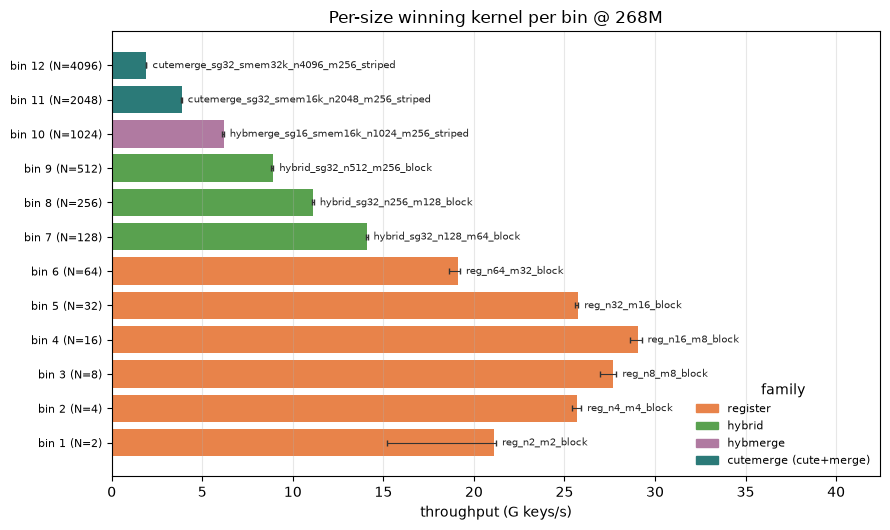

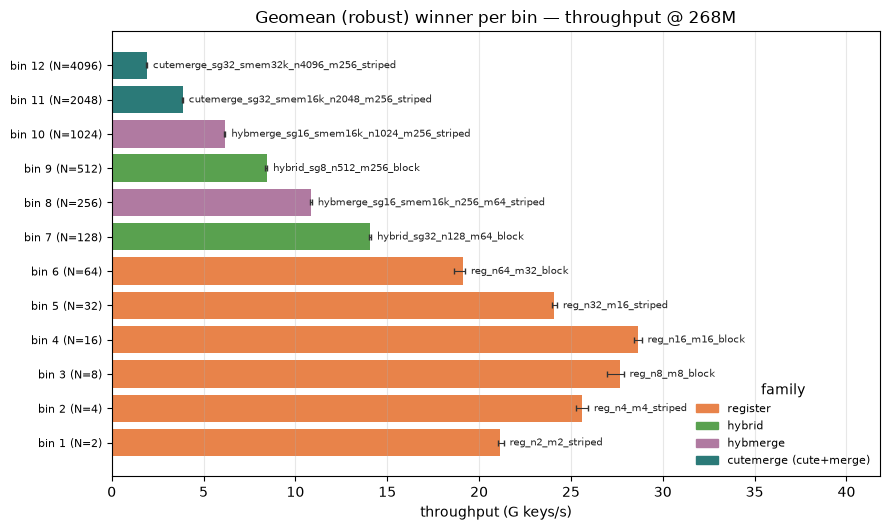

In [4]:
def plot_winners_bar(agg, n_keys, basis="winner"):
    sub = agg[agg["n_keys"] == n_keys]
    if basis == "geomean":
        gw = geo_win.reset_index()[["bin", "kernel"]]
        sel = sub.merge(gw, on=["bin", "kernel"])
        title = f"Geomean (robust) winner per bin — throughput @ {n_keys // 10**6}M"
    else:
        sel = sub.loc[sub.groupby("bin")["gkeys_s"].idxmax()]
        title = f"Per-size winning kernel per bin @ {n_keys // 10**6}M"
    sel = sel.sort_values("N")

    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(sel))))
    y = np.arange(len(sel))
    ax.barh(y, sel["gkeys_s"],
            color=[FAMILY_COLORS.get(f, "#888") for f in sel["family"]])
    ax.errorbar(sel["gkeys_s"], y,
                xerr=[sel["gkeys_s"] - sel["lo"], sel["hi"] - sel["gkeys_s"]],
                fmt="none", ecolor="#333", elinewidth=0.8, capsize=2)
    ax.set_yticks(y)
    ax.set_yticklabels([f"bin {int(b)} (N={int(n)})"
                        for b, n in zip(sel["bin"], sel["N"])], fontsize=8)
    for yi, (_, row) in zip(y, sel.iterrows()):
        ax.text(row["hi"], yi, "  " + row["kernel"].replace("segsort_", ""),
                va="center", ha="left", fontsize=7, color="#222")
    ax.set_xlabel("throughput (G keys/s)")
    ax.set_title(title)
    ax.set_xlim(0, sel["hi"].max() * 1.45)
    ax.grid(axis="x", alpha=0.3)
    handles = [plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS[f])
               for f in FAMILY_COLORS if f in set(sel["family"])]
    labs = [FAMILY_LABEL[f] for f in FAMILY_COLORS if f in set(sel["family"])]
    ax.legend(handles, labs, frameon=False, fontsize=8, title="family", loc="lower right")
    fig.tight_layout()


plot_winners_bar(agg, n_keys=max(key_counts), basis="winner")
plot_winners_bar(agg, n_keys=max(key_counts), basis="geomean")

## Throughput vs key count per bin

Thoughput vs key count for all kernels per bin

Winner is bolded and labeled.
If the geomean winner is different from the winner, it will be dashed and labeled as well.

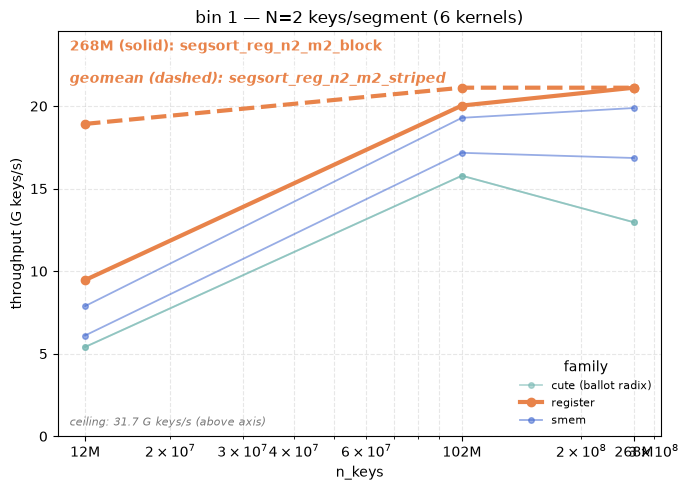

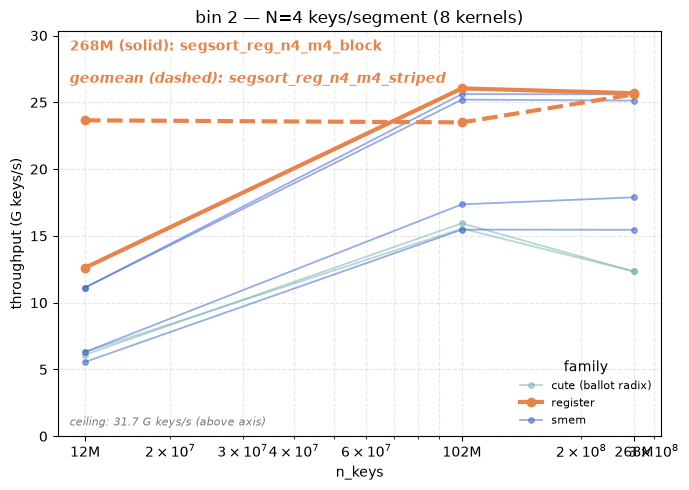

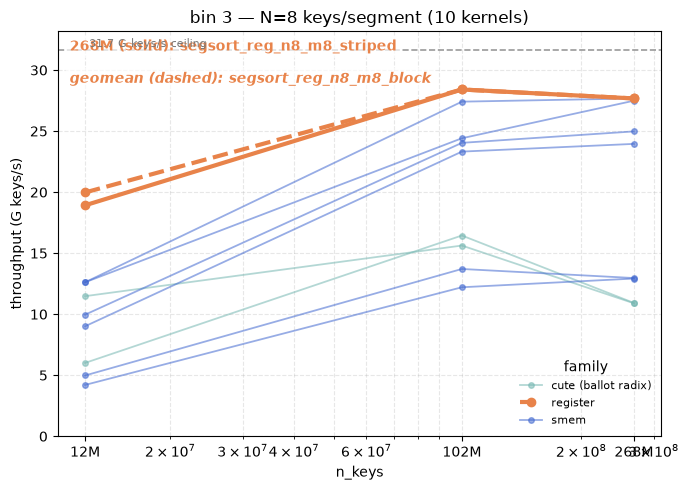

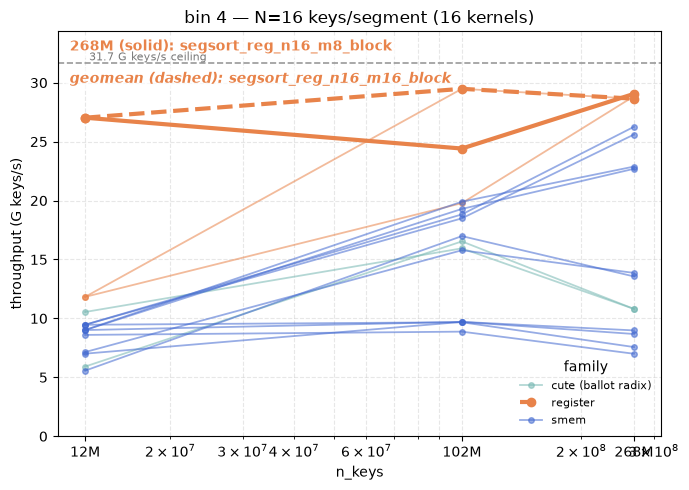

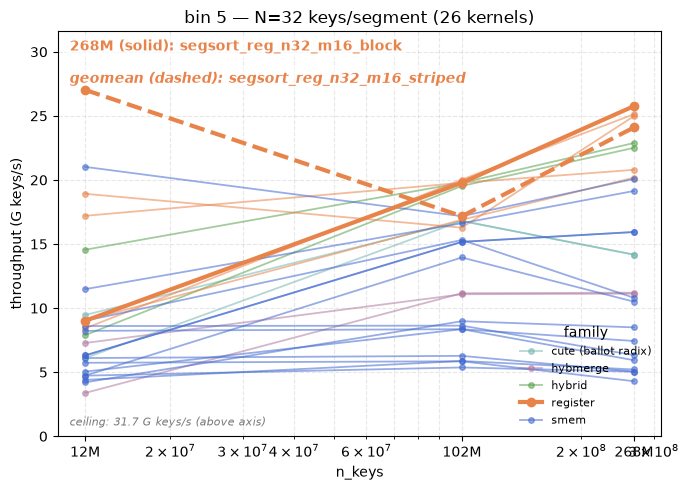

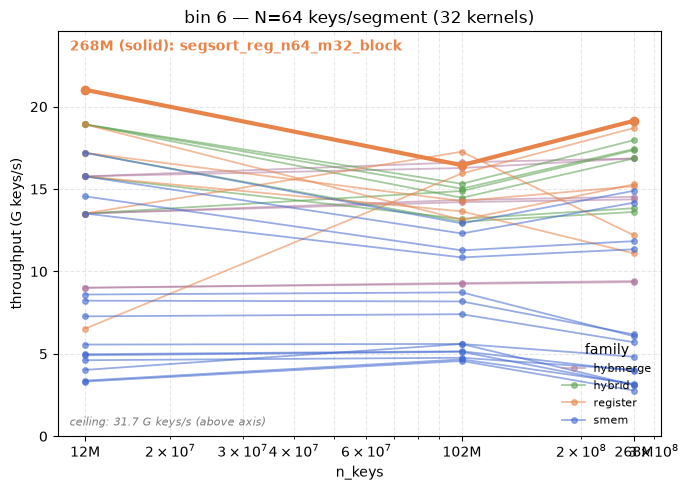

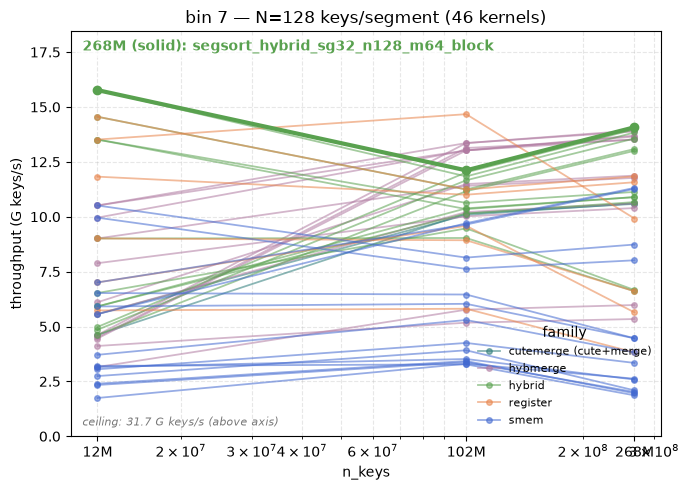

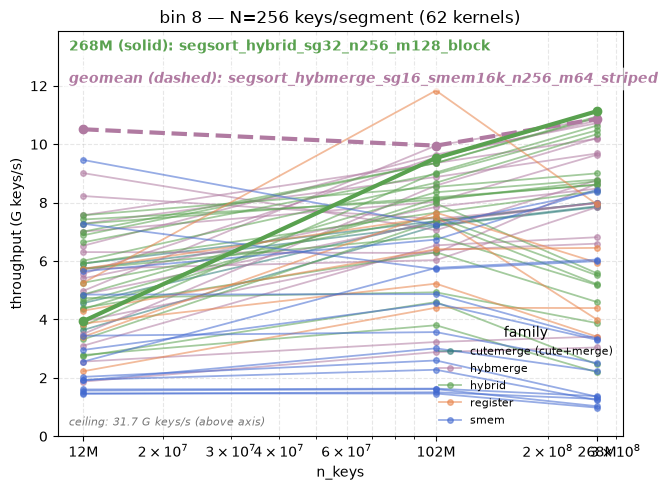

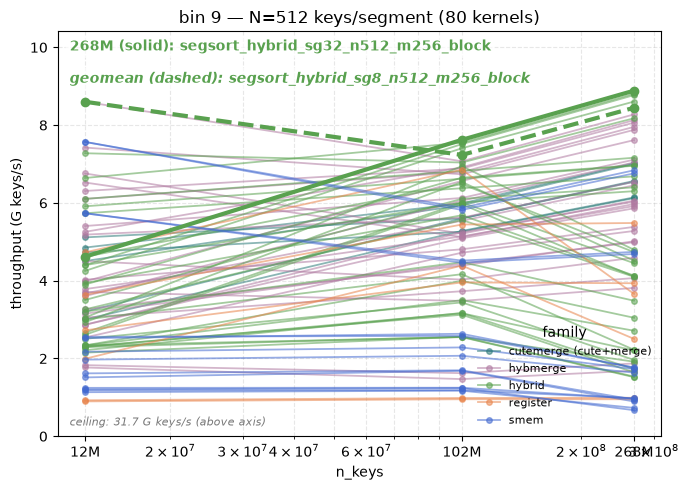

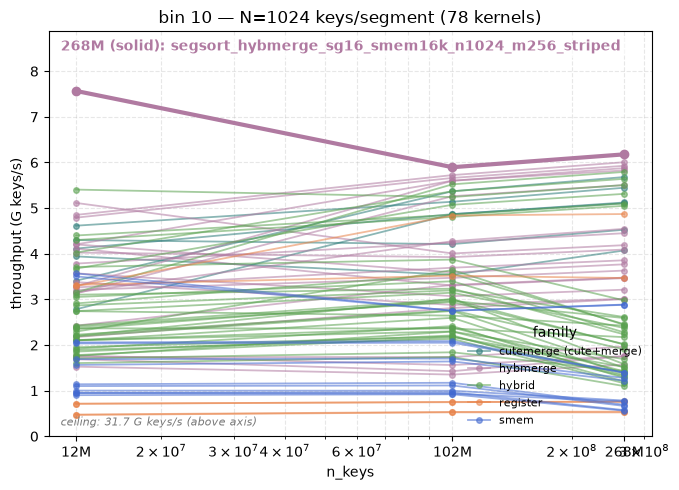

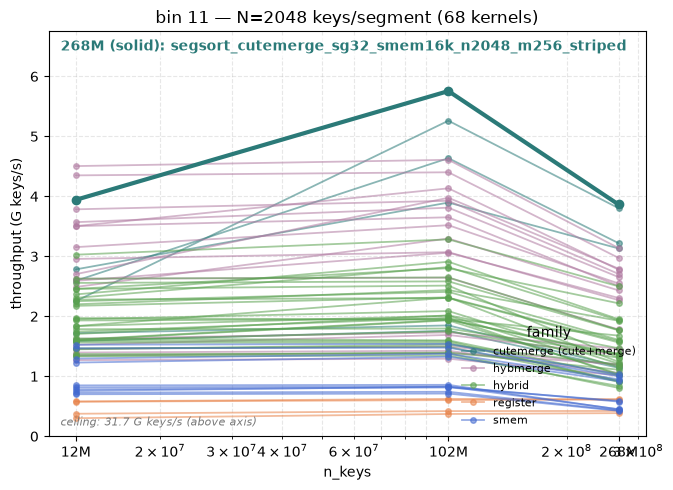

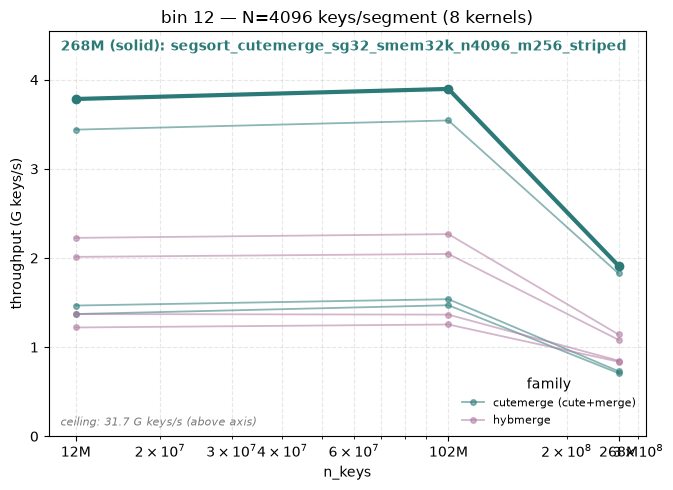

In [5]:
def plot_bin(agg, bin_id, ax=None):
    g = (agg[agg["bin"] == bin_id][["family", "kernel", "n_keys", "gkeys_s"]]
         .sort_values("n_keys"))
    if g.empty:
        raise ValueError(f"no data for bin {bin_id}")
    seg_n = seg[bin_id]

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    ref_nk = g["n_keys"].max()
    ref = g[g["n_keys"] == ref_nk]
    max_kernel = ref.loc[ref["gkeys_s"].idxmax(), "kernel"]
    geo_kernel = geo_win.loc[bin_id, "kernel"] if bin_id in geo_win.index else None

    def fam_of(kernel):
        return g.loc[g["kernel"] == kernel, "family"].iloc[0]

    seen = set()
    for (family, kernel), k in g.groupby(["family", "kernel"]):
        is_max = kernel == max_kernel
        is_geo = kernel == geo_kernel
        hi = is_max or is_geo
        ax.plot(
            k["n_keys"], k["gkeys_s"],
            marker="o", markersize=6 if hi else 4,
            linewidth=3.0 if hi else 1.3,
            linestyle="--" if (is_geo and not is_max) else "-",
            alpha=1.0 if hi else 0.55,
            zorder=6 if is_max else (5 if is_geo else 2),
            color=FAMILY_COLORS.get(family, "#888"),
            label=FAMILY_LABEL.get(family, family) if family not in seen else None,
        )
        seen.add(family)

    ax.text(0.02, 0.98, f"268M (solid): {max_kernel}", transform=ax.transAxes,
            ha="left", va="top", fontsize=10, fontweight="bold",
            color=FAMILY_COLORS.get(fam_of(max_kernel), "#333"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))
    if geo_kernel is not None and geo_kernel != max_kernel:
        ax.text(0.02, 0.90, f"geomean (dashed): {geo_kernel}",
                transform=ax.transAxes, ha="left", va="top", fontsize=10,
                fontweight="bold", fontstyle="italic",
                color=FAMILY_COLORS.get(fam_of(geo_kernel), "#333"),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))

    ax.set_ylim(bottom=0)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)   # headroom
    top = ax.get_ylim()[1]
    if CEIL_GKEYS <= top:
        ax.axhline(CEIL_GKEYS, color="#999", linestyle="--", linewidth=1.2)
        ax.text(g["n_keys"].min(), CEIL_GKEYS, f" {CEIL_GKEYS:.1f} G keys/s ceiling",
                va="bottom", ha="left", fontsize=8, color="#777")
    else:
        ax.text(0.02, 0.02, f"ceiling: {CEIL_GKEYS:.1f} G keys/s (above axis)",
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=8, color="#777", style="italic")

    ax.set_xscale("log")
    ax.set_xticks(sorted(g["n_keys"].unique()))
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v/1e6)}M"))
    ax.set_xlabel("n_keys")
    ax.set_ylabel("throughput (G keys/s)")
    ax.set_title(f"bin {bin_id} — N={seg_n} keys/segment "
                 f"({g['kernel'].nunique()} kernels)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, fontsize=8, title="family", loc="lower right")


for _bin in bins:
    plot_bin(agg, _bin)
    plt.tight_layout()
    plt.show()

## Subgroup size comparison (8,16,32)


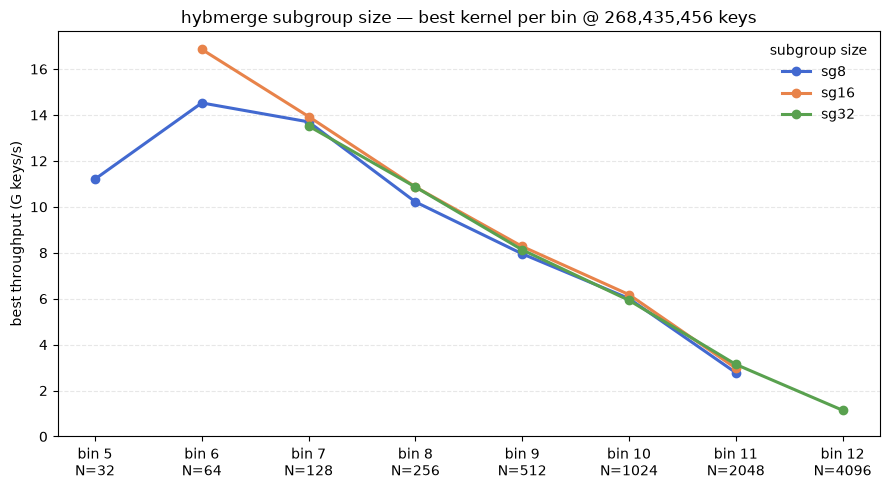

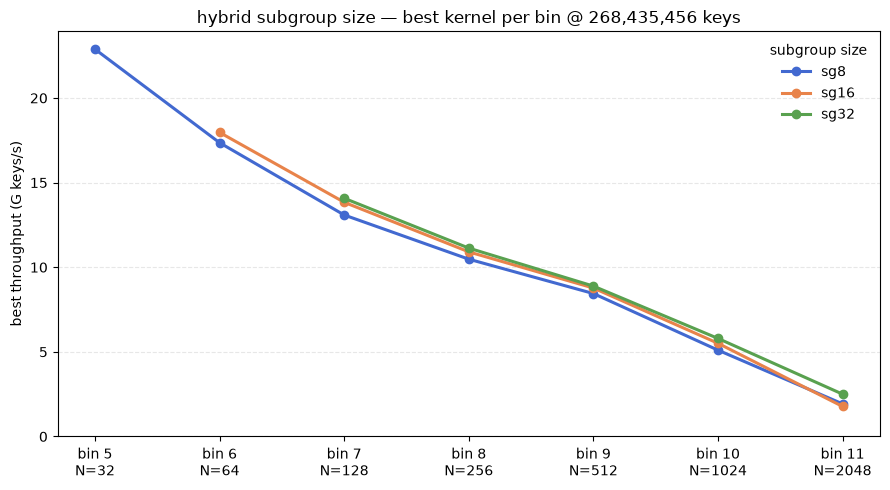

In [6]:
def plot_subgroup_study(agg, family):
    ref_nk = max(key_counts)
    sub = agg[(agg["family"] == family) & (agg["n_keys"] == ref_nk)]
    if sub.empty:
        return None
    best = (sub.groupby(["bin", "subgroups"])["gkeys_s"].max()
               .unstack("subgroups").sort_index())

    idx = list(best.index)
    x = np.arange(len(idx))
    labels = [f"bin {b}\nN={seg[b]}" for b in idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    for sg in sorted(best.columns):
        ax.plot(x, best[sg], marker="o", markersize=6, linewidth=2.2,
                color=SG_COLORS.get(sg, "#888"), label=f"sg{sg}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("best throughput (G keys/s)")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{family} subgroup size — best kernel per bin @ {ref_nk:,} keys")
    ax.legend(frameon=False, title="subgroup size", loc="upper right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()


plot_subgroup_study(agg, "hybmerge")
plot_subgroup_study(agg, "hybrid")

## Best kernel per bin, by family


memory,reg,cute,smem,hybrid,hybmerge,cutemerge
bin,,,,,,
1,21.113402,12.962025,19.883495,NaN,NaN,NaN
2,25.680503,12.337349,25.600000,NaN,NaN,NaN
3,27.675676,10.922667,27.675676,NaN,NaN,NaN
4,29.049645,10.807388,26.256410,NaN,NaN,NaN
5,25.761006,14.173010,20.078431,22.882682,11.206587,NaN
6,19.140187,NaN,14.894545,17.964912,16.855967,NaN
7,11.838150,NaN,11.314917,14.075601,13.931973,10.611399
8,7.937984,NaN,8.445361,11.130435,10.864721,8.000000
9,5.483266,NaN,6.838063,8.885033,8.274747,7.025729


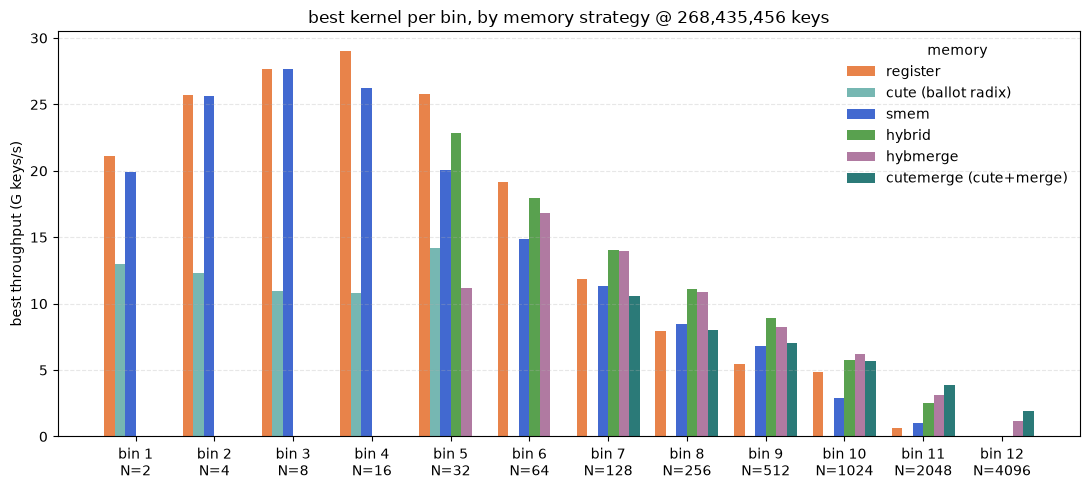

In [7]:
def plot_memory_by_bin(agg):
    ref_nk = max(key_counts)
    sub = agg[agg["n_keys"] == ref_nk]
    best = sub.groupby(["bin", "memory"])["gkeys_s"].max().unstack("memory").sort_index()
    order = [m for m in ["reg", "cute", "smem", "hybrid", "hybmerge", "cutemerge"] if m in best.columns]
    best = best[order]

    idx = list(best.index)
    x = np.arange(len(idx))
    width = 0.8 / len(order)

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, mem in enumerate(order):
        ax.bar(x + (i - (len(order) - 1) / 2) * width, best[mem], width,
               color=FAMILY_COLORS.get(mem, "#888"), label=FAMILY_LABEL.get(mem, mem))
    ax.set_xticks(x)
    ax.set_xticklabels([f"bin {b}\nN={seg[b]}" for b in idx])
    ax.set_ylabel("best throughput (G keys/s)")
    ax.set_title(f"best kernel per bin, by memory strategy @ {ref_nk:,} keys")
    ax.legend(frameon=False, title="memory", loc="upper right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return best


plot_memory_by_bin(agg)

## Speedup heatmaps vs smem


,memory,store,bin,n_keys,gkeys_s,base,speedup
0,cute,block,1,12400000,5.405971,6.103516,0.885714
1,cute,block,1,102400000,15.782828,17.170330,0.919192
2,cute,block,1,268435456,12.962025,16.855967,0.768987
3,cute,block,2,12400000,6.306966,11.129940,0.566667
4,cute,block,2,102400000,15.547649,25.201613,0.616931
...,...,...,...,...,...,...,...
205,reg,striped,10,102400000,4.837461,2.750880,1.758514
206,reg,striped,10,268435456,4.870392,2.886540,1.687277
207,reg,striped,11,12400000,0.575915,1.525706,0.377474
208,reg,striped,11,102400000,0.603049,1.540927,0.391355


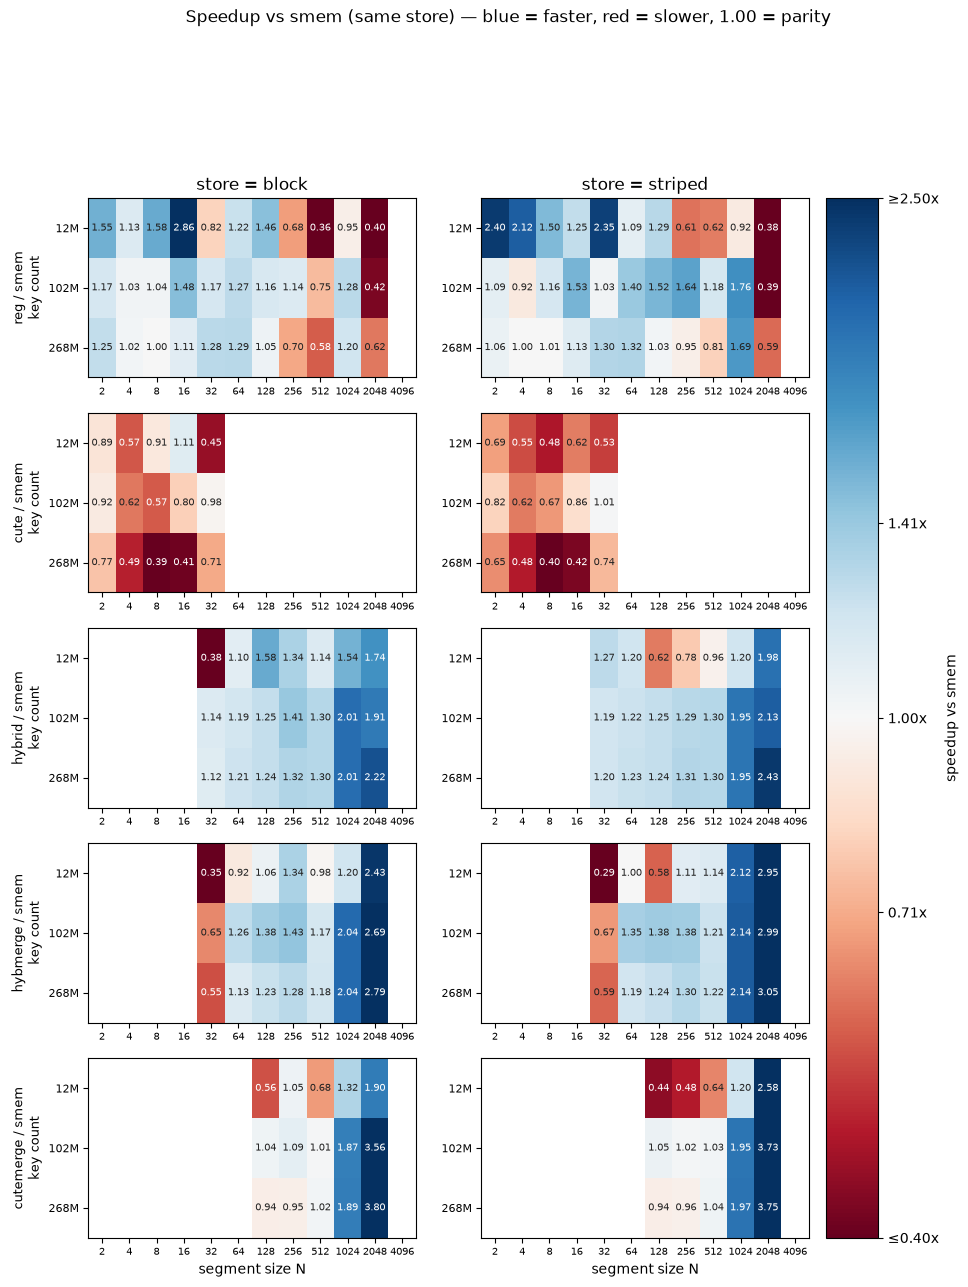

In [8]:
def speedup_heatmaps(agg, baseline="smem", saturate=2.5):
    best = agg.groupby(["memory", "store", "bin", "n_keys"])["gkeys_s"].max().reset_index()
    base = (best[best["memory"] == baseline]
            .rename(columns={"gkeys_s": "base"}).drop(columns="memory"))
    m = best[best["memory"] != baseline].merge(base, on=["store", "bin", "n_keys"])
    m["speedup"] = m["gkeys_s"] / m["base"]

    memories = [x for x in ["reg", "cute", "hybrid", "hybmerge", "cutemerge"] if x in m["memory"].values]
    stores = [x for x in ["block", "striped"] if x in m["store"].values]
    lim = float(np.log2(saturate))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    nrows, ncols = len(memories), len(stores)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 2.7 * nrows), squeeze=False)
    im = None
    for r, mem in enumerate(memories):
        for c, st in enumerate(stores):
            ax = axes[r][c]
            s = m[(m["memory"] == mem) & (m["store"] == st)]
            Z = s.pivot(index="n_keys", columns="bin", values="speedup").reindex(
                index=key_counts, columns=bins)
            logZ = np.log2(Z.values)
            im = ax.imshow(logZ, cmap="RdBu", norm=norm, aspect="auto")
            for i in range(Z.shape[0]):
                for j in range(Z.shape[1]):
                    v = Z.values[i, j]
                    if np.isnan(v):
                        continue
                    ink = "white" if abs(logZ[i, j]) > 0.6 * lim else "#222"
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color=ink)
            ax.set_xticks(range(len(bins)))
            ax.set_xticklabels([seg[b] for b in bins], fontsize=7)
            ax.set_yticks(range(len(key_counts)))
            ax.set_yticklabels([f"{k // 10**6}M" for k in key_counts], fontsize=8)
            if r == 0:
                ax.set_title(f"store = {st}")
            if c == 0:
                ax.set_ylabel(f"{mem} / smem\nkey count", fontsize=9)
            if r == nrows - 1:
                ax.set_xlabel("segment size N")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.02)
    cbar.set_ticks(np.log2([1 / saturate, 0.71, 1.0, 1.41, saturate]))
    cbar.ax.set_yticklabels(["≤0.40x", "0.71x", "1.00x", "1.41x", "≥2.50x"])
    cbar.set_label(f"speedup vs {baseline}")
    fig.suptitle(f"Speedup vs {baseline} (same store) — blue = faster, "
                 f"red = slower, 1.00 = parity", y=1.02)
    return m


speedup_heatmaps(agg)

## Winner stability across key counts


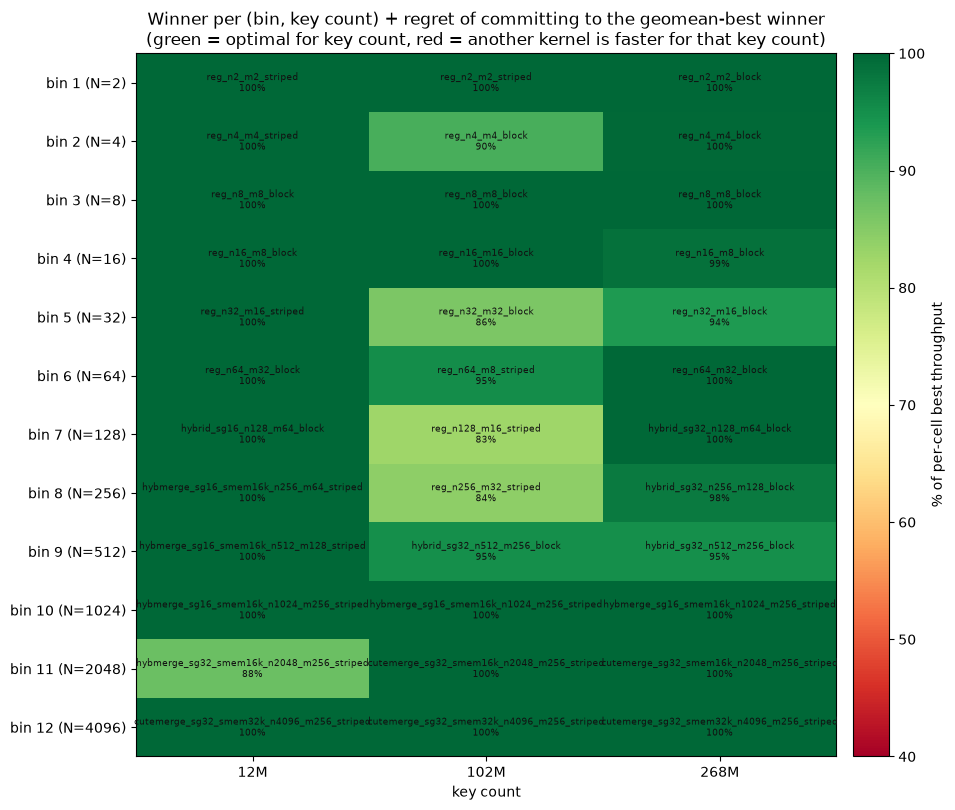

In [9]:
def winner_table(agg):
    tab = winners.pivot(index="bin", columns="n_keys", values="kernel")
    tab.columns = [f"{k // 10**6}M" for k in tab.columns]
    tab["stable"] = tab.nunique(axis=1) == 1
    return tab


def geomean_winners(agg):
    """Per bin, the kernel maximizing the geomean of its median throughput across
    key counts (only kernels present at every key count). Prebuilt as geo_win."""
    return geo_win


def plot_winner_stability(agg, commit_at="max"):
    if commit_at == "geomean":
        committed = geo_win["kernel"]
        commit_desc = "geomean-best"
    else:
        commit_nk = max(key_counts) if commit_at == "max" else min(key_counts)
        committed = winners[winners["n_keys"] == commit_nk].set_index("bin")["kernel"]
        commit_desc = f"{commit_nk // 10**6}M"
    win_by_cell = winners.set_index(["bin", "n_keys"])["kernel"]

    regret = pd.DataFrame(index=bins, columns=key_counts, dtype=float)
    label = pd.DataFrame(index=bins, columns=key_counts, dtype=object)
    for b in bins:
        k = committed.get(b)
        for nk in key_counts:
            got = agg[(agg["bin"] == b) & (agg["n_keys"] == nk)
                      & (agg["kernel"] == k)]["gkeys_s"]
            frac = (got.iloc[0] / cell_best[(b, nk)]) if len(got) else float("nan")
            regret.loc[b, nk] = 100 * frac
            label.loc[b, nk] = win_by_cell[(b, nk)].replace("segsort_", "")

    fig, ax = plt.subplots(figsize=(10, 0.6 * len(bins) + 1))
    im = ax.imshow(regret.values.astype(float), cmap="RdYlGn", vmin=40, vmax=100, aspect="auto")
    for i, b in enumerate(bins):
        for j, nk in enumerate(key_counts):
            ax.text(j, i, f"{label.loc[b, nk]}\n{regret.loc[b, nk]:.0f}%",
                    ha="center", va="center", fontsize=6.5, color="#111")
    ax.set_xticks(range(len(key_counts)))
    ax.set_xticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_yticks(range(len(bins)))
    ax.set_yticklabels([f"bin {b} (N={seg[b]})" for b in bins])
    ax.set_xlabel("key count")
    ax.set_title(f"Winner per (bin, key count) + regret of committing to the "
                 f"{commit_desc} winner\n"
                 f"(green = optimal for key count, red = another kernel is faster for that key count)")
    fig.colorbar(im, ax=ax, pad=0.02).set_label("% of per-cell best throughput")
    fig.tight_layout()


plot_winner_stability(agg, commit_at="geomean")

## Striped vs block store — reg kernels


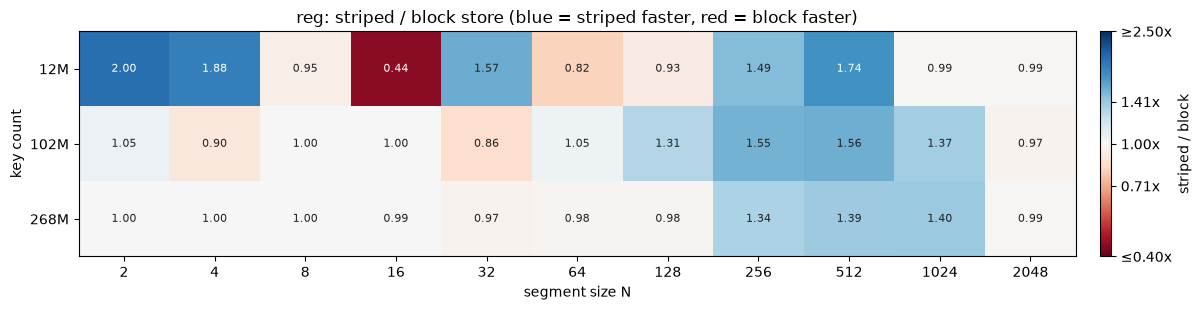

In [10]:
def plot_store_heatmap(agg, memory="reg", saturate=2.5):
    sub = agg[agg["memory"] == memory]
    best = sub.groupby(["store", "bin", "n_keys"])["gkeys_s"].max().reset_index()
    blk = best[best["store"] == "block"].rename(columns={"gkeys_s": "block"}).drop(columns="store")
    strp = best[best["store"] == "striped"].rename(columns={"gkeys_s": "striped"}).drop(columns="store")
    m = blk.merge(strp, on=["bin", "n_keys"])
    m["ratio"] = m["striped"] / m["block"]

    b_idx = sorted(m["bin"].unique())
    Z = m.pivot(index="n_keys", columns="bin", values="ratio").reindex(
        index=key_counts, columns=b_idx)
    logZ = np.log2(Z.values)
    lim = float(np.log2(saturate))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, ax = plt.subplots(figsize=(1.0 * len(b_idx) + 2, 3.2))
    im = ax.imshow(logZ, cmap="RdBu", norm=norm, aspect="auto")
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z.values[i, j]
            if np.isnan(v):
                continue
            ink = "white" if abs(logZ[i, j]) > 0.6 * lim else "#222"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=ink)
    ax.set_xticks(range(len(b_idx)))
    ax.set_xticklabels([seg[b] for b in b_idx])
    ax.set_yticks(range(len(key_counts)))
    ax.set_yticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_xlabel("segment size N")
    ax.set_ylabel("key count")
    ax.set_title(f"{memory}: striped / block store (blue = striped faster, red = block faster)")
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_ticks(np.log2([1 / saturate, 0.71, 1.0, 1.41, saturate]))
    cbar.ax.set_yticklabels(["≤0.40x", "0.71x", "1.00x", "1.41x", "≥2.50x"])
    cbar.set_label("striped / block")
    fig.tight_layout()


plot_store_heatmap(agg, memory="reg")

## Achievable-throughput envelope

Best throughput across all families/stores per bin

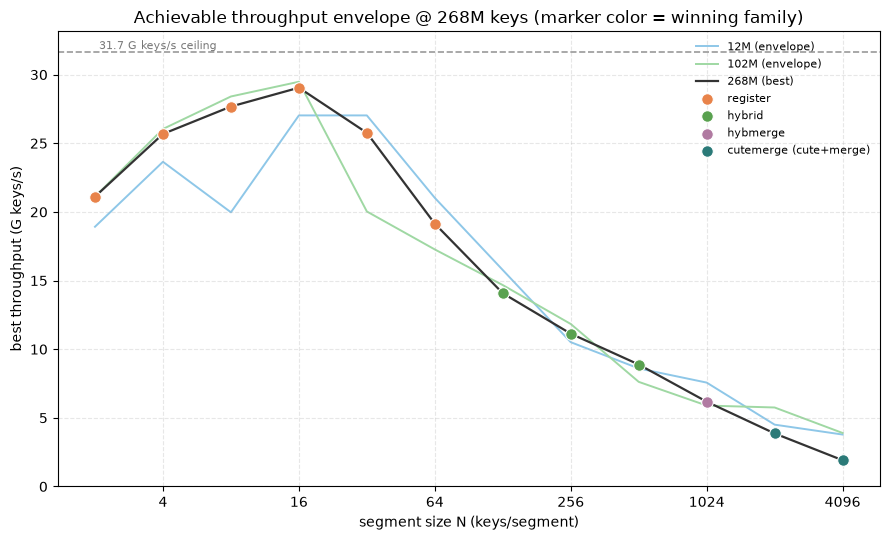

In [11]:
def plot_envelope(agg, ref_at="max"):
    ref_nk = max(key_counts) if ref_at == "max" else min(key_counts)
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # distinct light colors for the smaller-key-count envelopes (were all gray)
    env_palette = ["#8ec7e8", "#9fd8a3", "#c9b3e0"]   # light blue, light green, light purple
    smaller = [nk for nk in key_counts if nk != ref_nk]
    env_color = {nk: env_palette[i % len(env_palette)] for i, nk in enumerate(smaller)}
    for nk in smaller:
        e = agg[agg["n_keys"] == nk]
        env = e.loc[e.groupby("N")["gkeys_s"].idxmax()].sort_values("N")
        ax.plot(env["N"], env["gkeys_s"], color=env_color[nk], linewidth=1.4, zorder=1,
                label=f"{nk // 10**6}M (envelope)")

    e = agg[agg["n_keys"] == ref_nk]
    env = e.loc[e.groupby("N")["gkeys_s"].idxmax()].sort_values("N")
    ax.plot(env["N"], env["gkeys_s"], color="#333", linewidth=1.6, zorder=2,
            label=f"{ref_nk // 10**6}M (best)")
    seen = set()
    for _, row in env.iterrows():
        fam = row["family"]
        ax.scatter(row["N"], row["gkeys_s"], s=70, zorder=3,
                   color=FAMILY_COLORS.get(fam, "#888"), edgecolor="white", linewidth=0.8,
                   label=FAMILY_LABEL.get(fam, fam) if fam not in seen else None)
        seen.add(fam)

    if CEIL_GKEYS <= ax.get_ylim()[1] * 1.2:
        ax.axhline(CEIL_GKEYS, color="#999", linestyle="--", linewidth=1.2)
        ax.text(env["N"].min(), CEIL_GKEYS, f" {CEIL_GKEYS:.1f} G keys/s ceiling",
                va="bottom", ha="left", fontsize=8, color="#777")

    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel("best throughput (G keys/s)")
    ax.set_title(f"Achievable throughput envelope @ {ref_nk // 10**6}M keys "
                 f"(marker color = winning family)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    fig.tight_layout()


plot_envelope(agg)

## Envelope: per-size winner vs geomean winner


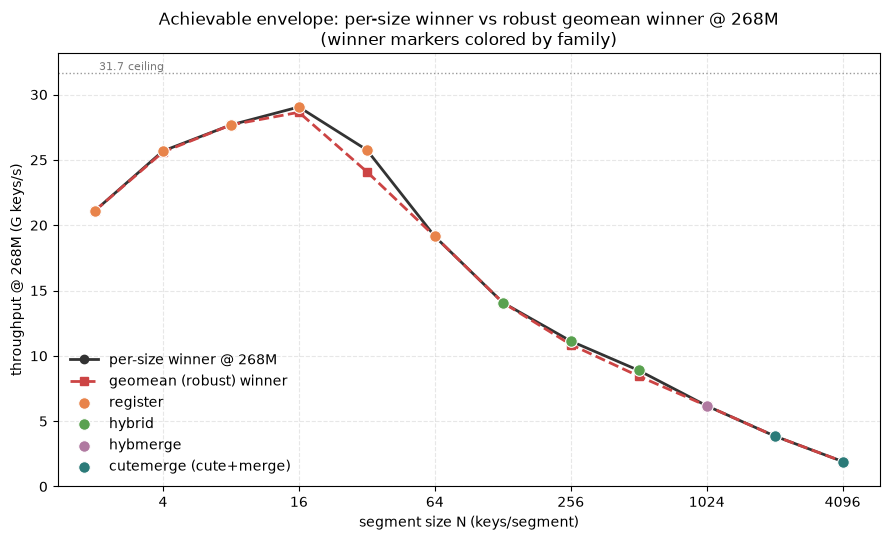

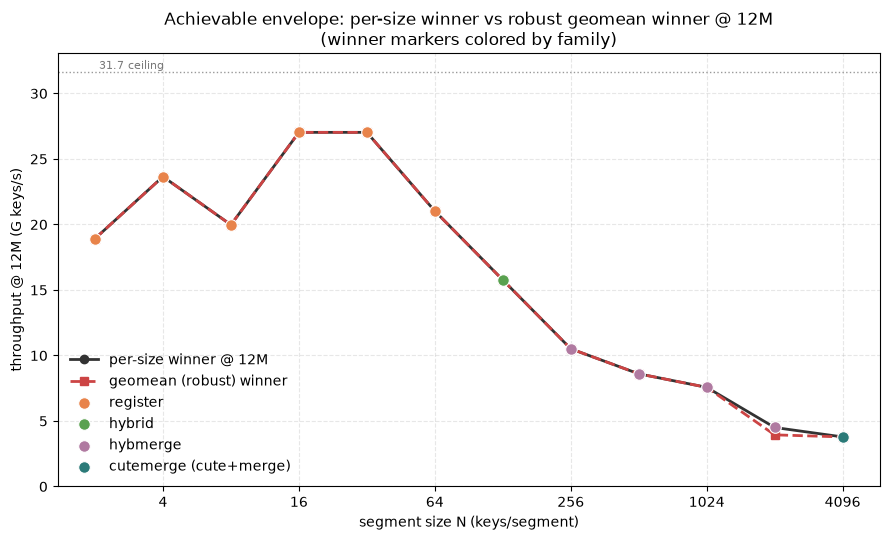

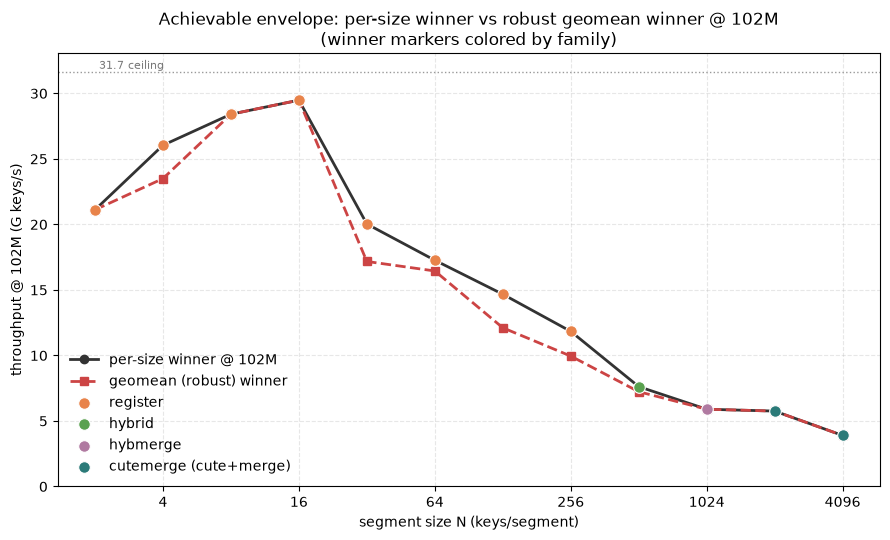

In [12]:
def plot_envelope_compare(agg, n_keys=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    sub = agg[agg["n_keys"] == nk]
    win = sub.loc[sub.groupby("N")["gkeys_s"].idxmax()].sort_values("N")

    gw = geo_win["kernel"]
    geo_rows = []
    for b, kern in gw.items():
        r = sub[(sub["bin"] == b) & (sub["kernel"] == kern)]
        if not r.empty:
            geo_rows.append(r.iloc[0])
    geo = pd.DataFrame(geo_rows).sort_values("N")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(win["N"], win["gkeys_s"], marker="o", color="#333", linewidth=2.0,
            zorder=3, label=f"per-size winner @ {nk // 10**6}M")
    ax.plot(geo["N"], geo["gkeys_s"], marker="s", color="#c44", linewidth=2.0,
            linestyle="--", zorder=3, label="geomean (robust) winner")
    seen = set()
    for _, row in win.iterrows():
        fam = row["family"]
        ax.scatter(row["N"], row["gkeys_s"], s=70, zorder=4,
                   color=FAMILY_COLORS.get(fam, "#888"), edgecolor="white", linewidth=0.8,
                   label=FAMILY_LABEL.get(fam, fam) if fam not in seen else None)
        seen.add(fam)

    if CEIL_GKEYS <= ax.get_ylim()[1] * 1.2:
        ax.axhline(CEIL_GKEYS, color="#999", linestyle=":", linewidth=1.0)
        ax.text(win["N"].min(), CEIL_GKEYS, f" {CEIL_GKEYS:.1f} ceiling",
                va="bottom", ha="left", fontsize=8, color="#777")

    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel(f"throughput @ {nk // 10**6}M (G keys/s)")
    ax.set_title(f"Achievable envelope: per-size winner vs robust geomean winner "
                 f"@ {nk // 10**6}M\n(winner markers colored by family)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()

    out = win[["N", "kernel", "gkeys_s"]].merge(
        geo[["N", "kernel", "gkeys_s"]], on="N", suffixes=("_winner", "_geomean"))
    out["geomean/winner"] = out["gkeys_s_geomean"] / out["gkeys_s_winner"]

plot_envelope_compare(agg, n_keys=max(key_counts))
plot_envelope_compare(agg, n_keys=key_counts[0])
plot_envelope_compare(agg, n_keys=key_counts[1])

## Throughput over (N x M) per family

N=segment size, M=number of threads per segment

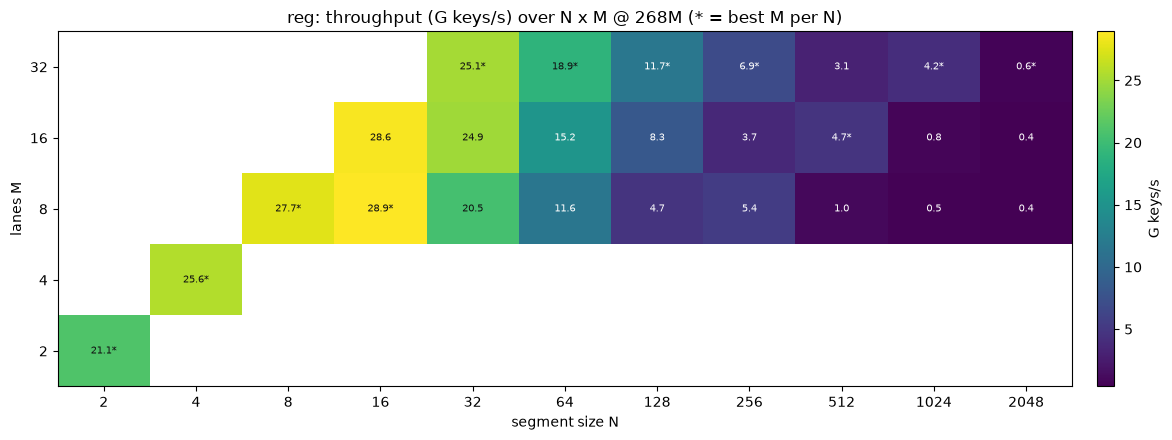

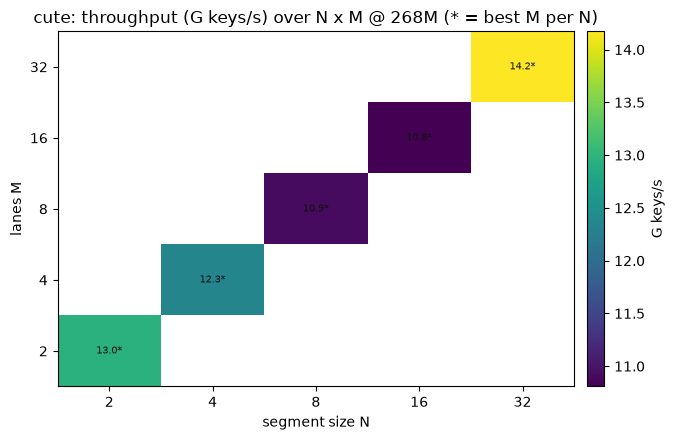

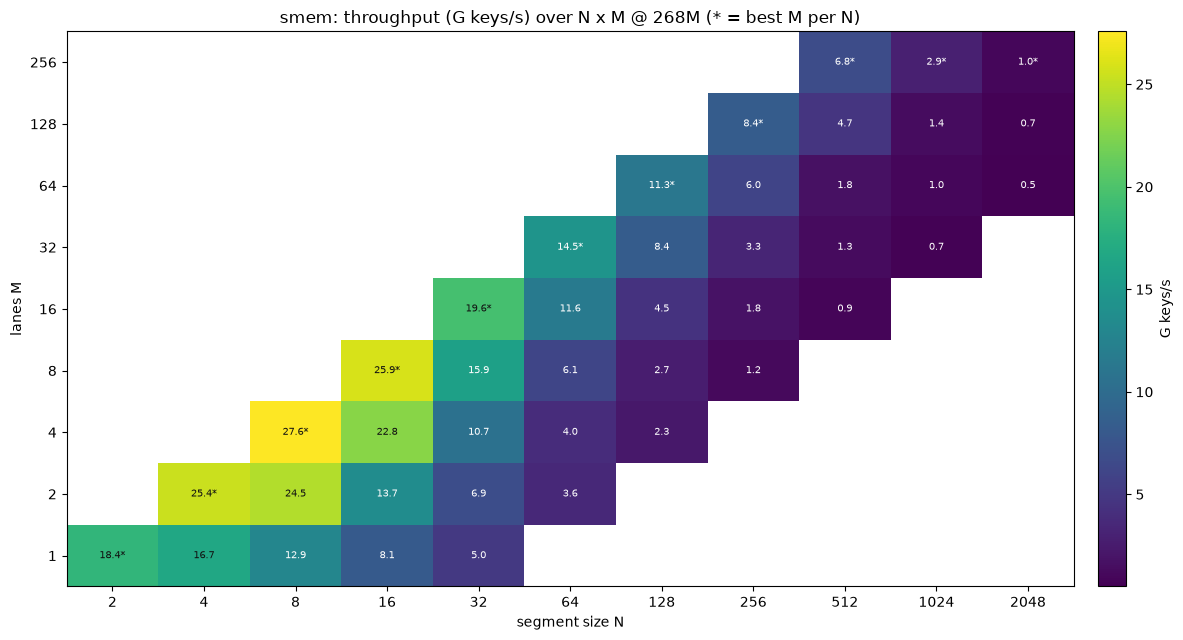

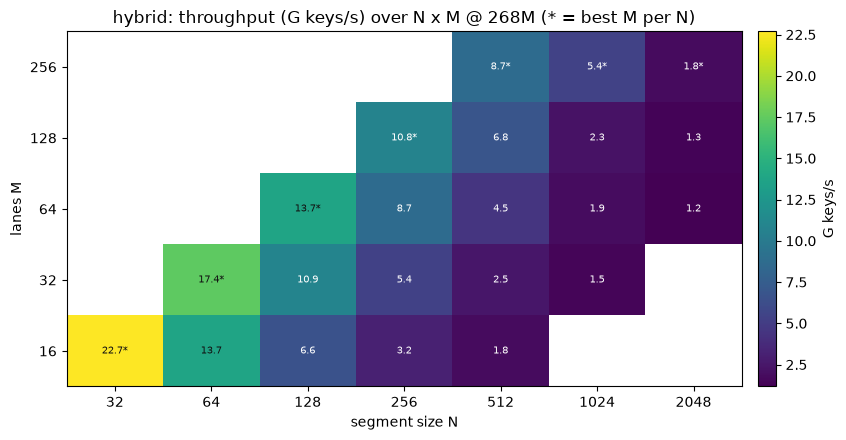

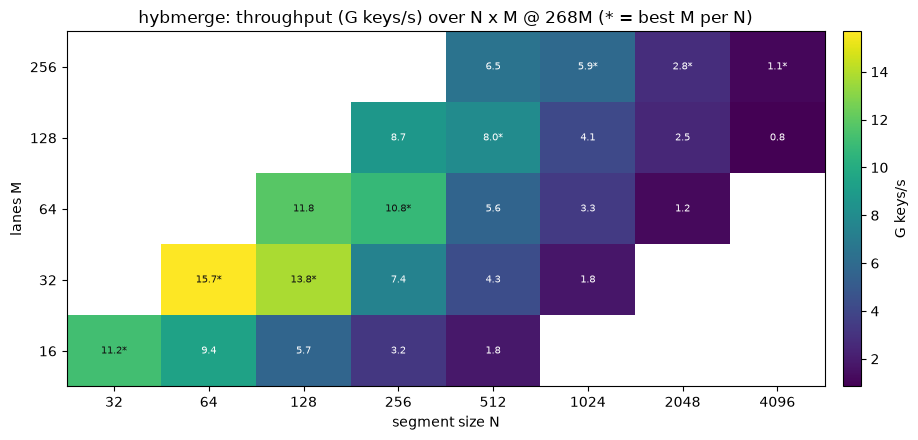

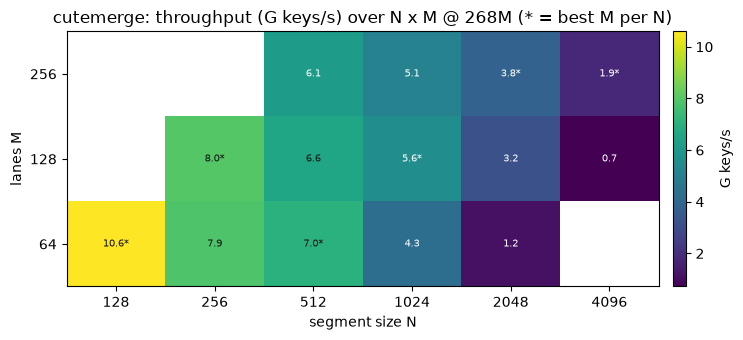

In [13]:
def plot_mn_tuning(agg, memory, n_keys=None, ax=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    sub = agg[(agg["memory"] == memory) & (agg["n_keys"] == nk)]
    if sub.empty:
        return None
    cell = sub.groupby(["N", "M"])["gkeys_s"].median().reset_index()
    Ns = sorted(cell["N"].unique())
    Ms = sorted(cell["M"].unique())
    Z = cell.pivot(index="M", columns="N", values="gkeys_s").reindex(index=Ms, columns=Ns)

    if ax is None:
        _, ax = plt.subplots(figsize=(1.0 * len(Ns) + 2, 0.5 * len(Ms) + 2))
    im = ax.imshow(Z.values.astype(float), cmap="viridis", aspect="auto", origin="lower")
    for j, N in enumerate(Ns):
        col = Z[N]
        best_m = col.idxmax() if col.notna().any() else None
        for i, M in enumerate(Ms):
            v = Z.loc[M, N]
            if np.isnan(v):
                continue
            star = "*" if M == best_m else ""
            ax.text(j, i, f"{v:.1f}{star}", ha="center", va="center", fontsize=7,
                    color="white" if v < np.nanmax(Z.values) * 0.6 else "#111")
    ax.set_xticks(range(len(Ns)))
    ax.set_xticklabels(Ns)
    ax.set_yticks(range(len(Ms)))
    ax.set_yticklabels(Ms)
    ax.set_xlabel("segment size N")
    ax.set_ylabel("lanes M")
    ax.set_title(f"{memory}: throughput (G keys/s) over N x M @ {nk // 10**6}M (* = best M per N)")
    plt.colorbar(im, ax=ax, pad=0.02, label="G keys/s")
    plt.tight_layout()


for _mem in ["reg", "cute", "smem", "hybrid", "hybmerge", "cutemerge"]:
    plot_mn_tuning(agg, _mem)
    plt.show()

## Register vs shared memory (Hou et al Fig 9 analog)


memory,hybmerge,reg,smem,reg/smem,reg/hybmerge
N,,,,,
2,NaN,21.113402,18.369731,1.149358,NaN
4,NaN,25.640252,21.507649,1.192146,NaN
8,NaN,27.675676,24.464413,1.131263,NaN
16,NaN,28.744214,13.712103,2.096266,NaN
32,11.168511,24.534864,7.965841,3.080009,2.196789
64,14.448376,15.226976,5.264617,2.892323,1.053888
128,12.695308,8.262064,3.580921,2.307246,0.650797
256,8.715249,5.167493,2.369442,2.180890,0.592926
512,6.001623,3.084442,1.682680,1.833053,0.513935


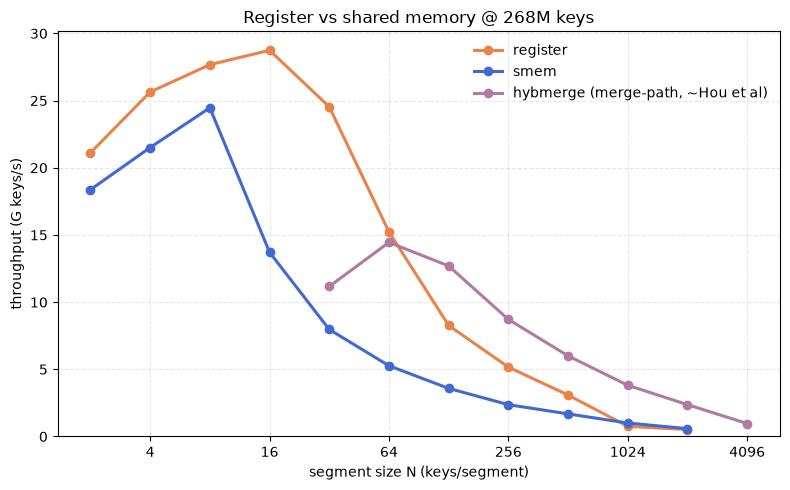

In [14]:
def plot_reg_vs_smem(agg, n_keys=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    mems = ["reg", "smem", "hybmerge"]
    sub = agg[(agg["memory"].isin(mems)) & (agg["n_keys"] == nk)]
    best = sub.groupby(["memory", "N"])["gkeys_s"].median().reset_index()
    piv = best.pivot(index="N", columns="memory", values="gkeys_s").sort_index()

    labels = {"reg": "register", "smem": "smem",
              "hybmerge": "hybmerge (merge-path, ~Hou et al)"}
    fig, ax = plt.subplots(figsize=(8, 5))
    for m in mems:
        if m not in piv:
            continue
        s = piv[m].dropna()
        ax.plot(s.index, s.values, marker="o", color=FAMILY_COLORS[m],
                linewidth=2.2, label=labels[m])
    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel("throughput (G keys/s)")
    ax.set_title(f"Register vs shared memory @ {nk // 10**6}M keys")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()
    if "smem" in piv:
        piv["reg/smem"] = piv["reg"] / piv["smem"]
    if "hybmerge" in piv:
        piv["reg/hybmerge"] = piv["reg"] / piv["hybmerge"]
    return piv


plot_reg_vs_smem(agg)

## CuteSort in-register vs register-based bitonic sort


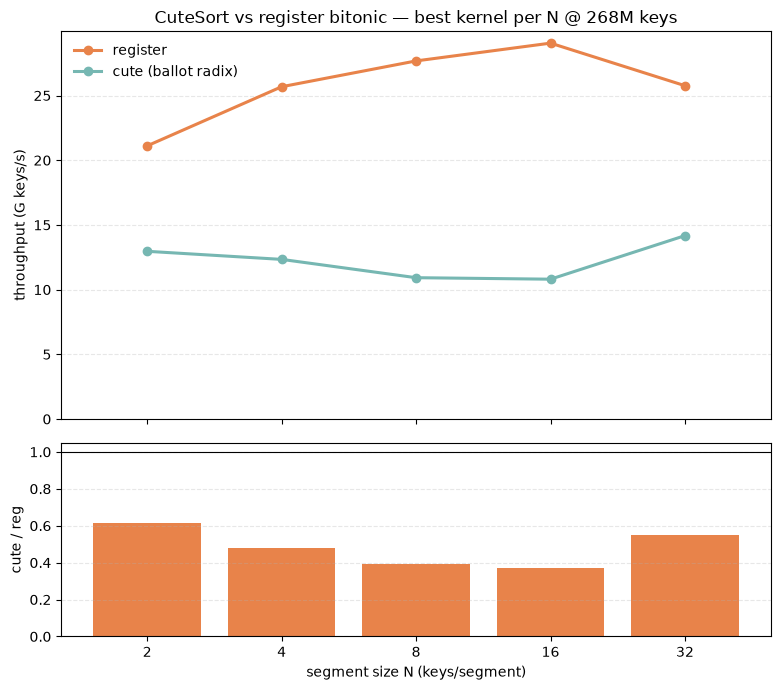

In [15]:
def cute_vs_reg(agg, n_keys=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    mems = ["reg", "cute"]
    sub = agg[(agg["memory"].isin(mems)) & (agg["n_keys"] == nk)]
    # best (max) kernel per family per N -- reg has several M/store variants;
    # compare each family's best so the head-to-head is fair.
    best = sub.groupby(["memory", "N"])["gkeys_s"].max().reset_index()
    piv = best.pivot(index="N", columns="memory", values="gkeys_s").sort_index()
    # cute only exists on the small-segment tier; restrict to N where it ran.
    piv = piv.dropna(subset=["cute"]) if "cute" in piv else piv

    if "cute" not in piv or piv.empty:
        print("no cute rows found in agg -- run the cute experiments first")
        return piv

    # only a handful of discrete segment sizes -> even categorical x on both
    # panels (a shared log axis would squish these 5 points against the edge).
    ns = [int(n) for n in piv.index]
    x = np.arange(len(ns))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    for m in mems:
        if m not in piv:
            continue
        ax1.plot(x, piv[m].values, marker="o", color=FAMILY_COLORS[m],
                 linewidth=2.2, label=FAMILY_LABEL[m])
    ax1.set_ylim(bottom=0)
    ax1.set_ylabel("throughput (G keys/s)")
    ax1.set_title(f"CuteSort vs register bitonic — best kernel per N @ {nk // 10**6}M keys")
    ax1.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax1.legend(frameon=False)

    piv["cute/reg"] = piv["cute"] / piv["reg"]
    ratio = piv["cute/reg"].values
    colors = [FAMILY_COLORS["cute"] if r >= 1.0 else FAMILY_COLORS["reg"] for r in ratio]
    ax2.bar(x, ratio, color=colors)
    ax2.axhline(1.0, color="black", linewidth=0.8)
    ax2.set_ylabel("cute / reg")
    ax2.set_xlabel("segment size N (keys/segment)")
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(n) for n in ns])
    ax2.grid(True, axis="y", linestyle="--", alpha=0.3)

    fig.tight_layout()
    plt.show()


cute_vs_reg(agg)

## cutemerge vs hybmerge

cutemerge starts winning around N=2048. At N=2048, 256 elements are sorted in registers.
at this point, the 32 subgroupBallot calls become less expensive.

A future benchmark should include larger N with more workgroup memory.

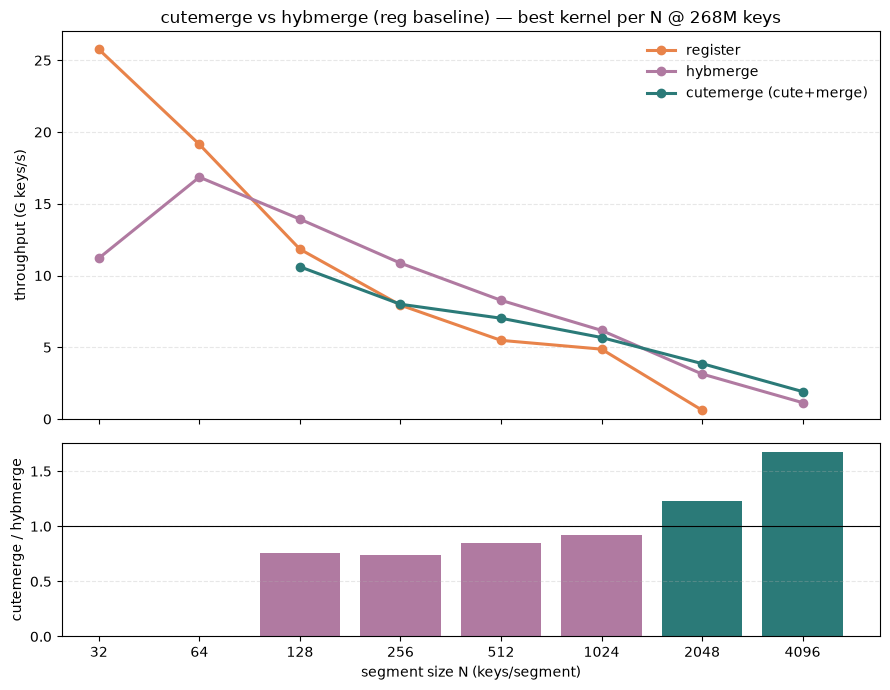

In [16]:
def cutemerge_vs_hybmerge(agg, n_keys=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    mems = ["reg", "hybmerge", "cutemerge"]
    sub = agg[(agg["memory"].isin(mems)) & (agg["n_keys"] == nk)]
    best = sub.groupby(["memory", "N"])["gkeys_s"].max().reset_index()
    piv = best.pivot(index="N", columns="memory", values="gkeys_s").sort_index()
    # merge tier only: keep N where cutemerge/hybmerge actually ran.
    merge_fams = [m for m in ["hybmerge", "cutemerge"] if m in piv]
    if merge_fams:
        piv = piv.dropna(subset=merge_fams, how="all")
    if "cutemerge" not in piv or piv["cutemerge"].dropna().empty:
        print("no cutemerge rows found in agg -- run the cutemerge experiments first")
        return piv

    ns = [int(n) for n in piv.index]
    x = np.arange(len(ns))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    for m in mems:
        if m not in piv:
            continue
        ax1.plot(x, piv[m].values, marker="o", color=FAMILY_COLORS[m],
                 linewidth=2.2, label=FAMILY_LABEL[m])
    ax1.set_ylim(bottom=0)
    ax1.set_ylabel("throughput (G keys/s)")
    ax1.set_title(f"cutemerge vs hybmerge (reg baseline) — best kernel per N @ {nk // 10**6}M keys")
    ax1.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax1.legend(frameon=False)

    if "hybmerge" in piv:
        piv["cutemerge/hybmerge"] = piv["cutemerge"] / piv["hybmerge"]
        ratio = piv["cutemerge/hybmerge"].values
        colors = [FAMILY_COLORS["cutemerge"] if r >= 1.0 else FAMILY_COLORS["hybmerge"]
                  for r in ratio]
        ax2.bar(x, ratio, color=colors)
        ax2.axhline(1.0, color="black", linewidth=0.8)
        ax2.set_ylabel("cutemerge / hybmerge")
    ax2.set_xlabel("segment size N (keys/segment)")
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(n) for n in ns])
    ax2.grid(True, axis="y", linestyle="--", alpha=0.3)

    fig.tight_layout()
    plt.show()


cutemerge_vs_hybmerge(agg)

## Winning family over (N, key count)

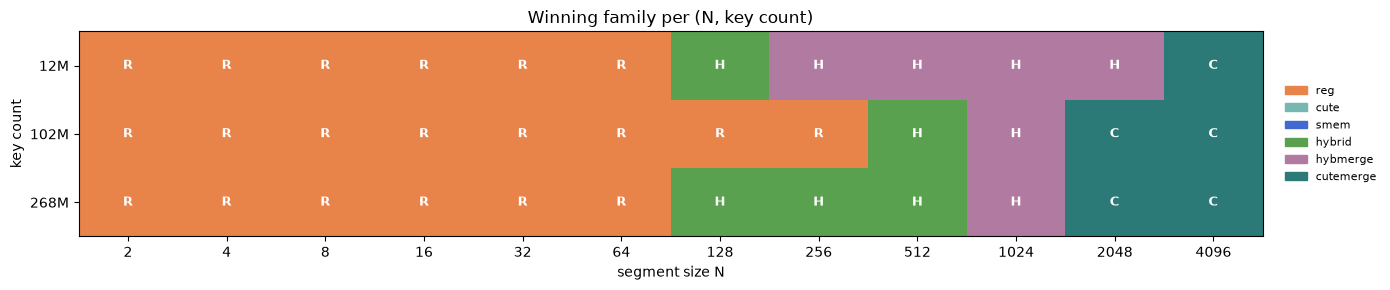

In [17]:
def plot_decision_map(agg):
    fam_order = [f for f in ["reg", "cute", "smem", "hybrid", "hybmerge", "cutemerge"]
                 if f in set(agg["family"].unique())]
    cmap = ListedColormap([FAMILY_COLORS[f] for f in fam_order])
    norm = BoundaryNorm(range(len(fam_order) + 1), cmap.N)

    fam_best = agg.groupby(["bin", "n_keys", "family"])["gkeys_s"].max().reset_index()
    win = fam_best.loc[fam_best.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()]
    b_idx = sorted(win["bin"].unique())
    fam_idx = {f: i for i, f in enumerate(fam_order)}

    Z = np.full((len(key_counts), len(b_idx)), np.nan)
    lbl = {}
    for _, row in win.iterrows():
        i = key_counts.index(row["n_keys"])
        j = b_idx.index(row["bin"])
        Z[i, j] = fam_idx[row["family"]]
        lbl[(i, j)] = row["family"][0].upper()

    fig, ax = plt.subplots(figsize=(1.0 * len(b_idx) + 2, 3))
    ax.imshow(Z, cmap=cmap, norm=norm, aspect="auto")
    for (i, j), t in lbl.items():
        ax.text(j, i, t, ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.set_xticks(range(len(b_idx)))
    ax.set_xticklabels([seg[b] for b in b_idx])
    ax.set_yticks(range(len(key_counts)))
    ax.set_yticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_xlabel("segment size N")
    ax.set_ylabel("key count")
    ax.set_title("Winning family per (N, key count)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS[f]) for f in fam_order]
    ax.legend(handles, fam_order, frameon=False, fontsize=8,
              loc="center left", bbox_to_anchor=(1.01, 0.5))
    fig.tight_layout()

plot_decision_map(agg)

## workgroup memory budget: 32k vs 16k (same kernel, larger workgroup)


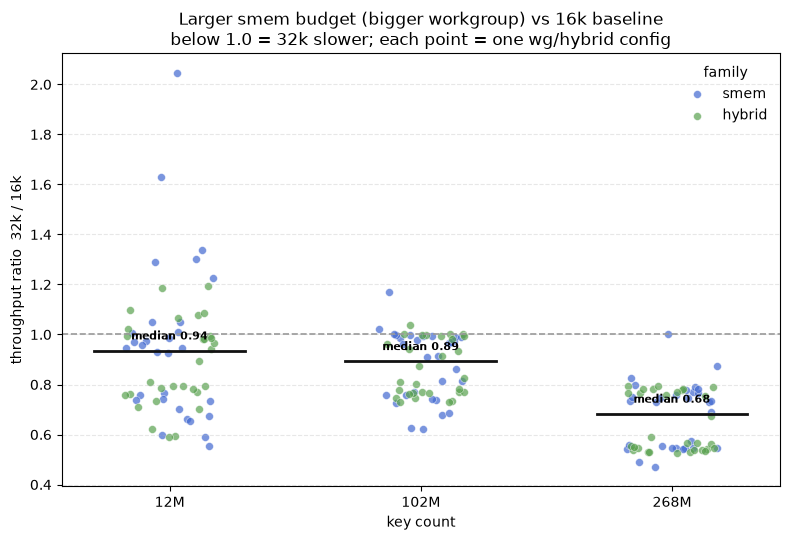

In [18]:
def plot_smem_budget_compare(agg):
    d = agg.copy()
    d["base"] = d["kernel"].str.replace("_smem32k", "", regex=False)
    d["budget"] = np.where(d["kernel"].str.endswith("_smem32k"), "32k", "16k")
    has32 = set(d.loc[d["budget"] == "32k", "base"])
    d = d[d["base"].isin(has32)]

    piv = d.pivot_table(index=["base", "memory", "n_keys"], columns="budget",
                        values="gkeys_s").reset_index()
    piv["ratio"] = piv["32k"] / piv["16k"]

    kcs = sorted(piv["n_keys"].unique())
    xpos = {nk: i for i, nk in enumerate(kcs)}
    rng = np.random.default_rng(0)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    for mem in ("smem", "hybrid"):
        s = piv[piv["memory"] == mem]
        x = [xpos[nk] + rng.uniform(-0.18, 0.18) for nk in s["n_keys"]]
        ax.scatter(x, s["ratio"], s=32, alpha=0.7, color=FAMILY_COLORS[mem],
                   label=FAMILY_LABEL[mem], edgecolor="white", linewidth=0.4)
    for nk in kcs:
        mval = piv.loc[piv["n_keys"] == nk, "ratio"].median()
        ax.plot([xpos[nk] - 0.3, xpos[nk] + 0.3], [mval, mval], color="#111", linewidth=2, zorder=5)
        ax.annotate(f"median {mval:.2f}", (xpos[nk], mval), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8, fontweight="bold")

    ax.axhline(1.0, color="#999", linestyle="--", linewidth=1.2)
    ax.set_xticks(range(len(kcs)))
    ax.set_xticklabels([f"{nk // 10**6}M" for nk in kcs])
    ax.set_xlabel("key count")
    ax.set_ylabel("throughput ratio  32k / 16k")
    ax.set_title("Larger smem budget (bigger workgroup) vs 16k baseline\n"
                 "below 1.0 = 32k slower; each point = one wg/hybrid config")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, title="family")
    fig.tight_layout()


plot_smem_budget_compare(agg)

## Coefficient of variation (CV) heatmaps


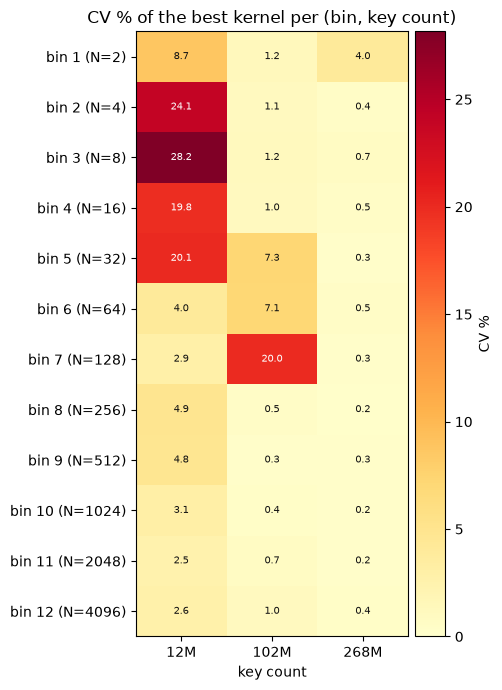

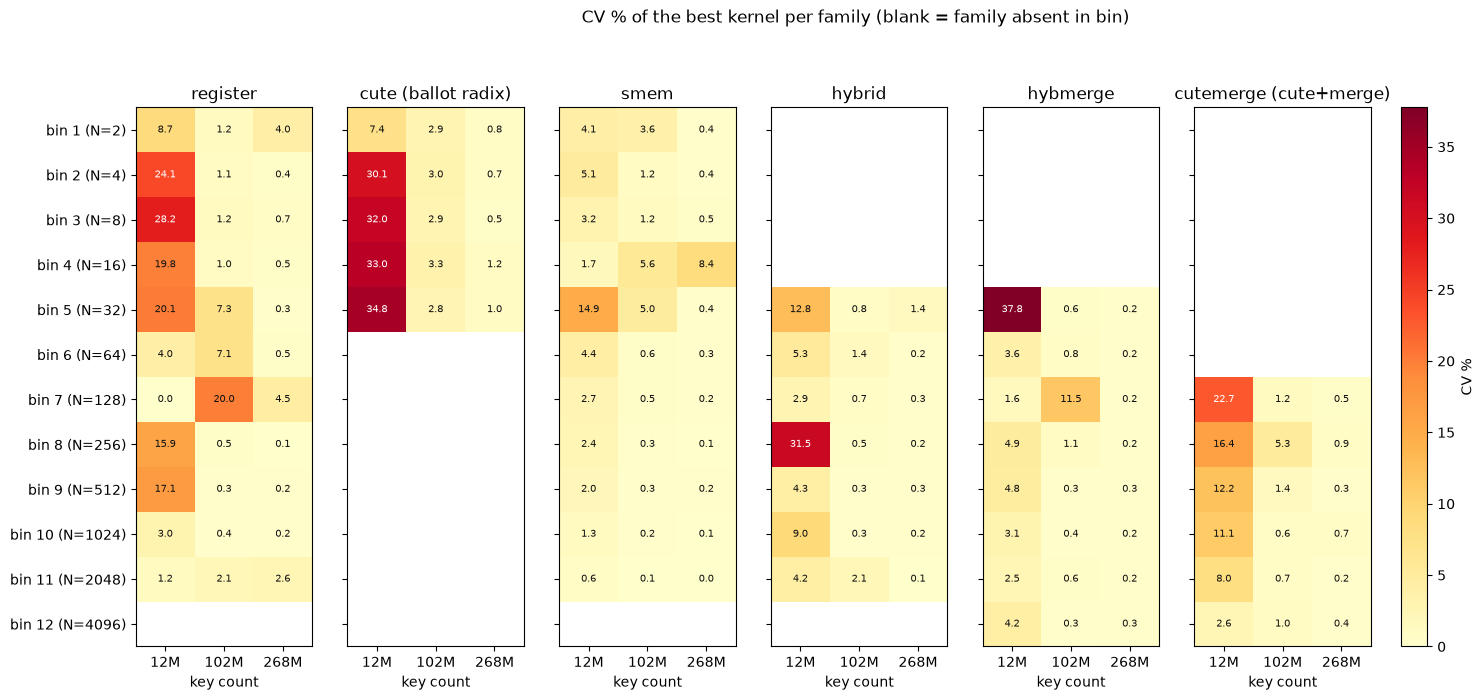

In [19]:
def _draw_cv(ax, Z, b_idx, key_counts, title, vmax):
    im = ax.imshow(Z, cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
                    color="#111" if v < 0.6 * vmax else "white")
    ax.set_xticks(range(len(key_counts)))
    ax.set_xticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_yticks(range(len(b_idx)))
    ax.set_yticklabels([f"bin {b} (N={seg[b]})" for b in b_idx])
    ax.set_title(title)
    return im


def plot_cv_heatmap_best(agg, vmax=None):
    win = agg.loc[agg.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()]
    Z = win.pivot(index="bin", columns="n_keys", values="cv").reindex(
        index=bins, columns=key_counts).values
    vmax = vmax or float(np.nanmax(Z))
    fig, ax = plt.subplots(figsize=(5, 0.5 * len(bins) + 1))
    im = _draw_cv(ax, Z, bins, key_counts, "CV % of the best kernel per (bin, key count)", vmax)
    ax.set_xlabel("key count")
    fig.colorbar(im, ax=ax, pad=0.02, label="CV %")
    fig.tight_layout()
    return Z


def plot_cv_heatmap_by_family(agg, vmax=None):
    fams = [f for f in ["reg", "cute", "smem", "hybrid", "hybmerge", "cutemerge"] if f in agg["family"].unique()]
    zs = {}
    for fam in fams:
        sf = agg[agg["family"] == fam]
        w = sf.loc[sf.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()]
        zs[fam] = w.pivot(index="bin", columns="n_keys", values="cv").reindex(
            index=bins, columns=key_counts).values
    vmax = vmax or float(np.nanmax([np.nanmax(z) for z in zs.values()]))

    fig, axes = plt.subplots(1, len(fams), figsize=(3.2 * len(fams), 0.5 * len(bins) + 1), sharey=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, fam in zip(axes, fams):
        im = _draw_cv(ax, zs[fam], bins, key_counts, FAMILY_LABEL.get(fam, fam), vmax)
        ax.set_xlabel("key count")
    for ax in axes[1:]:
        ax.set_ylabel("")
    fig.colorbar(im, ax=axes.tolist(), pad=0.02, label="CV %")
    fig.suptitle("CV % of the best kernel per family (blank = family absent in bin)", y=1.02)


plot_cv_heatmap_best(agg)
plot_cv_heatmap_by_family(agg)

### CV of the geomean winner

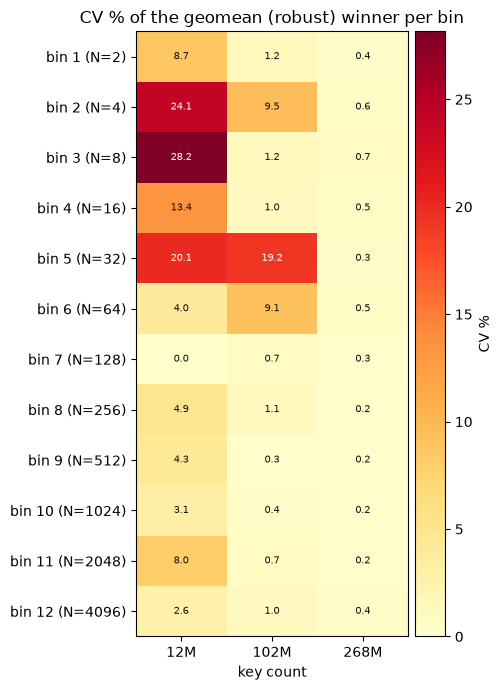

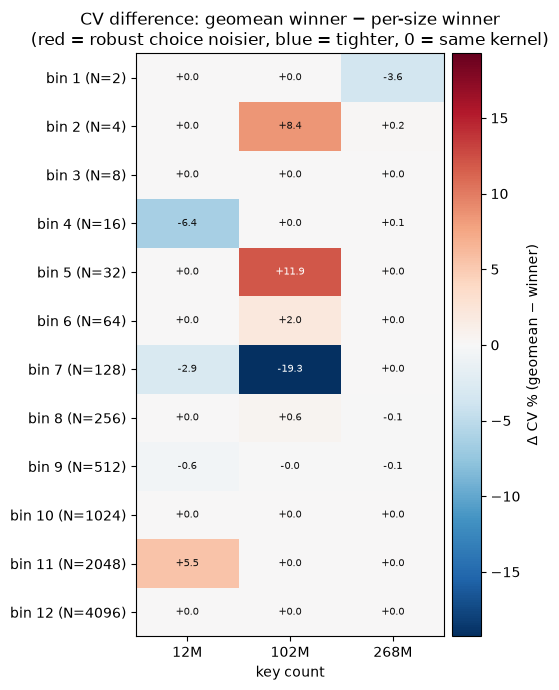

In [20]:
def _cv_pivot_for_kernels(agg, kernel_of):
    lut = agg.set_index(["bin", "n_keys", "kernel"])["cv"].to_dict()
    Z = np.full((len(bins), len(key_counts)), np.nan)
    for i, b in enumerate(bins):
        for j, nk in enumerate(key_counts):
            k = kernel_of(b, nk)
            if k is not None:
                Z[i, j] = lut.get((b, nk, k), np.nan)
    return Z


def plot_cv_heatmap_geomean(agg, vmax=None):
    gw = geo_win["kernel"]
    Z = _cv_pivot_for_kernels(agg, lambda b, nk: gw.get(b))
    vmax = vmax or float(np.nanmax(Z))
    fig, ax = plt.subplots(figsize=(5, 0.5 * len(bins) + 1))
    im = _draw_cv(ax, Z, bins, key_counts, "CV % of the geomean (robust) winner per bin", vmax)
    ax.set_xlabel("key count")
    fig.colorbar(im, ax=ax, pad=0.02, label="CV %")
    fig.tight_layout()


def plot_cv_compare(agg):
    win_k = winners.set_index(["bin", "n_keys"])["kernel"].to_dict()
    gw = geo_win["kernel"]
    Zw = _cv_pivot_for_kernels(agg, lambda b, nk: win_k.get((b, nk)))
    Zg = _cv_pivot_for_kernels(agg, lambda b, nk: gw.get(b))
    D = Zg - Zw

    lim = float(np.nanmax(np.abs(D)))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    fig, ax = plt.subplots(figsize=(5.5, 0.5 * len(bins) + 1))
    im = ax.imshow(D, cmap="RdBu_r", norm=norm, aspect="auto")
    for i in range(D.shape[0]):
        for j in range(D.shape[1]):
            v = D[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=7,
                    color="#111" if abs(v) < 0.6 * lim else "white")
    ax.set_xticks(range(len(key_counts)))
    ax.set_xticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_yticks(range(len(bins)))
    ax.set_yticklabels([f"bin {b} (N={seg[b]})" for b in bins])
    ax.set_xlabel("key count")
    ax.set_title("CV difference: geomean winner − per-size winner\n"
                 "(red = robust choice noisier, blue = tighter, 0 = same kernel)")
    fig.colorbar(im, ax=ax, pad=0.02).set_label("Δ CV % (geomean − winner)")
    fig.tight_layout()


plot_cv_heatmap_geomean(agg)
plot_cv_compare(agg)

## Roofline efficiency: % of memory-bandwidth ceiling

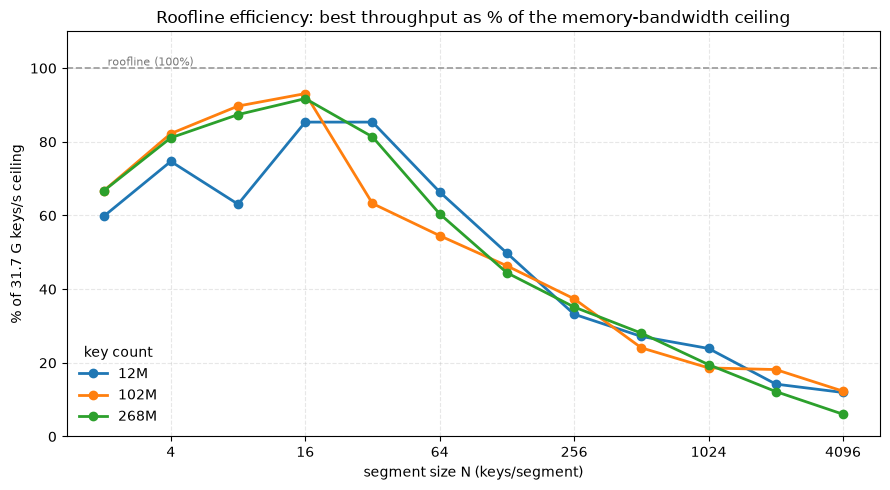

In [21]:
def plot_roofline_efficiency(agg):
    fig, ax = plt.subplots(figsize=(9, 5))
    env = None
    for nk in key_counts:
        e = agg[agg["n_keys"] == nk]
        env = e.loc[e.groupby("N")["gkeys_s"].idxmax()].sort_values("N")
        ax.plot(env["N"], 100 * env["gkeys_s"] / CEIL_GKEYS, marker="o",
                linewidth=2.0, label=f"{nk // 10**6}M")
    ax.axhline(100, color="#999", linestyle="--", linewidth=1.2)
    ax.text(agg["N"].min(), 100, " roofline (100%)", va="bottom", ha="left", fontsize=8, color="#777")
    ax.set_xscale("log", base=2)
    ax.set_ylim(0, 110)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel("% of 31.7 G keys/s ceiling")
    ax.set_title("Roofline efficiency: best throughput as % of the memory-bandwidth ceiling")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, title="key count")
    fig.tight_layout()

plot_roofline_efficiency(agg)

## Wall vs GPU time

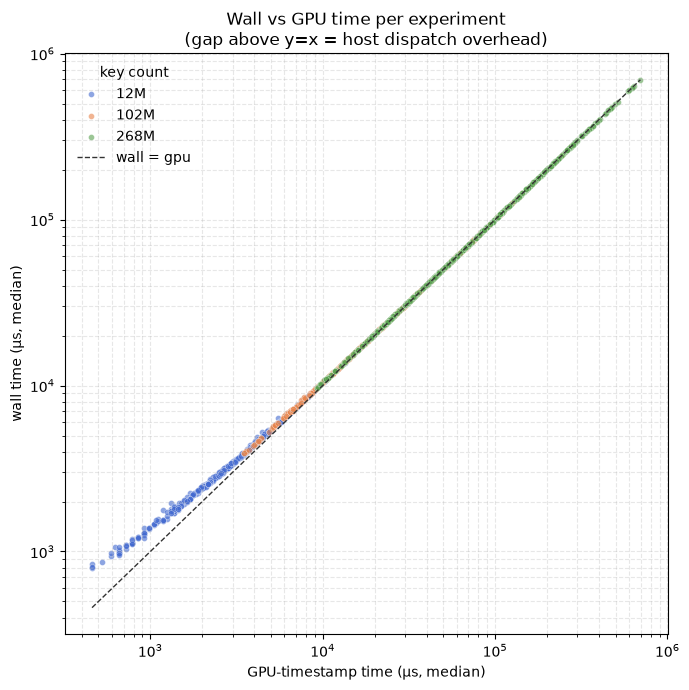

In [22]:
def plot_wall_vs_gpu(agg):
    g = agg[["kernel", "n_keys", "gpu_us", "wall_us"]]
    cmap = {nk: c for nk, c in zip(key_counts, ["#4269d0", "#e8834a", "#59a14f"])}

    fig, ax = plt.subplots(figsize=(7, 7))
    for nk in key_counts:
        s = g[g["n_keys"] == nk]
        ax.scatter(s["gpu_us"], s["wall_us"], s=18, alpha=0.6, color=cmap.get(nk, "#888"),
                   label=f"{nk // 10**6}M", edgecolor="white", linewidth=0.3)
    lo = min(g["gpu_us"].min(), g["wall_us"].min())
    hi = max(g["gpu_us"].max(), g["wall_us"].max())
    ax.plot([lo, hi], [lo, hi], color="#333", linewidth=1.0, linestyle="--", label="wall = gpu")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GPU-timestamp time (µs, median)")
    ax.set_ylabel("wall time (µs, median)")
    ax.set_title("Wall vs GPU time per experiment\n(gap above y=x = host dispatch overhead)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, title="key count")
    fig.tight_layout()


plot_wall_vs_gpu(agg)